# Linear regression, lambda KAN training on MNIST

In [9]:
import os
import sys

import torch
import torchmetrics
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt

from collections import defaultdict
from torch.nn.modules.pooling import MaxPool2d
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, utils
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from IPython.display import clear_output

import torch
import torchmetrics
import lightning as L
import torch.nn as nn
import matplotlib.pyplot as plt

from torchmetrics import MetricCollection
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassF1Score,
    MulticlassAUROC,
)
from lightning.pytorch.callbacks import ModelCheckpoint
from tbparse import SummaryReader

from kan import KANLayer
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
from source import lmdKANLayer

import random

from models import MnistLR, MnistMLP, Mnist_lmdSplineKAN, Mnist_tlmdSplineKAN, show_sensitivity

### Load [MNIST](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST):

In [10]:
batch_size = 256

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

mnist = datasets.MNIST(root="./", train=True, download=True, transform=transform)

(train_set, val_set,) = torch.utils.data.random_split(
    mnist, [50000, 10000], generator=torch.Generator().manual_seed(42)
)
test_set = datasets.MNIST(root="./", train=False, download=True, transform=transform)

val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True)

### Create LightningModule class

In [11]:
class LModel(L.LightningModule):
    def __init__(self, model, lr=0.001):
        super().__init__()
        self.save_hyperparameters(logger=False)

        # for optimizer and shaduler
        self.lr = lr

        # model
        self.model = model
        self.criterion = nn.CrossEntropyLoss()

        # metrics
        self.metrics = MetricCollection([
            MulticlassAccuracy(num_classes=10,),
            #MulticlassF1Score(num_classes=10,),
            #MulticlassAUROC(num_classes=10,)
        ])
        self.train_metrics = self.metrics.clone(postfix='/train')
        self.val_metrics = self.metrics.clone(postfix='/val')

    def configure_optimizers(self):
        # set optimizer
        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.lr,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",  # or 'step'
                "monitor": "loss" # only for self.log
            },
        }

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self.model(x)
        loss = self.criterion(out, y)
        self.train_metrics.update(out, y)
        self.log("loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self.model(x)
        self.val_metrics.update(out, y)

    def on_train_epoch_end(self):
        self.log_dict(self.train_metrics.compute())
        self.train_metrics.reset()

        val_metrics = self.val_metrics.compute()
        self.log_dict(val_metrics)
        self.val_metrics.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        out = self.model(x)
        self.metrics.update(out, y)

    def on_test_epoch_end(self):
        self.log_dict(self.metrics.compute())
        self.metrics.reset()

### Start training

#### MnistLR

In [4]:
checkpoint_callback = ModelCheckpoint(
    # dirpath='best_ckp/'
    save_last=True,
    every_n_epochs=1,
    save_top_k=1,
    save_weights_only=True,
    monitor="MulticlassAccuracy/val",
    filename="model",
    mode="max",
)

L.seed_everything(1755)

model = MnistLR() #Mnist_lmdSplineKAN() #MnistPrllSplineKAN() #MnistSplineKAN() #MnistSplineKAN() #MnistKAN() #MnistMLP() #MnistCNN() #MnistLR()
pl_model = LModel(model)
trainer = L.Trainer(
    max_epochs=20,
    callbacks=[checkpoint_callback],
    num_sanity_val_steps=0,
    log_every_n_steps=10,
    logger=L.pytorch.loggers.TensorBoardLogger(save_dir=f"./logs/{type(model).__name__}/"),
)

trainer.fit(
    model=pl_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

Seed set to 1755
c:\Users\Gavriil\VS_projects\lambda_KAN\.venv\lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | MnistLR          | 7.9 K  | train
1 | criterion     | CrossEntropyLoss | 0      | train
2 | metrics       | MetricCollection | 0      | train
3 | train_metrics | MetricCollection | 0      | train
4 | val_metrics   | MetricCollection | 0      | train
-----------------------------------------------------------
7.9 K     Trainable params
0         Non-trainable params
7.9 K     Total params
0.031     Total estimated model params size (MB)
11        Mo

Epoch 19: 100%|██████████| 196/196 [00:07<00:00, 27.75it/s, v_num=1, loss=0.279]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 196/196 [00:07<00:00, 27.53it/s, v_num=1, loss=0.279]


In [5]:
# Load the best checkpoint automatically (lightning tracks this for you)
trainer.test(
    model=pl_model, dataloaders=test_loader, verbose=True, ckpt_path="best"
)

Restoring states from the checkpoint path at ./logs/MnistLR/lightning_logs\version_1\checkpoints\model.ckpt
Loaded model weights from the checkpoint at ./logs/MnistLR/lightning_logs\version_1\checkpoints\model.ckpt


Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 40.06it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    MulticlassAccuracy     │    0.9249136447906494     │
└───────────────────────────┴───────────────────────────┘

[{'MulticlassAccuracy': 0.9249136447906494}]

In [14]:
#import pandas as pd
#import pytorch_lightning as L
#from pytorch_lightning.callbacks import ModelCheckpoint
#from typing import List, Any
#import os


def train_and_evaluate_model(
    model: Any,
    seed: int,
    train_loader,
    val_loader,
    test_loader,
    max_epochs: int = 20
) -> float:
    """
    Обучает модель с заданным seed и возвращает точность на тестовой выборке.
    
    Args:
        model: Модель для обучения
        seed: Значение seed для воспроизводимости
        train_loader: DataLoader для обучающей выборки
        val_loader: DataLoader для валидационной выборки
        test_loader: DataLoader для тестовой выборки
        max_epochs: Количество эпох обучения
        
    Returns:
        Accuracy на тестовой выборке
    """
    # Установка seed
    L.seed_everything(seed)
    
    # Настройка checkpoint callback
    checkpoint_callback = ModelCheckpoint(
        save_last=True,
        every_n_epochs=1,
        save_top_k=1,
        save_weights_only=True,
        monitor="MulticlassAccuracy/val",
        filename=f"model_seed_{seed}",
        mode="max",
    )
    
    # Создание Lightning модели
    pl_model = LModel(model)
    
    # Создание trainer
    trainer = L.Trainer(
        max_epochs=max_epochs,
        callbacks=[checkpoint_callback],
        num_sanity_val_steps=0,
        log_every_n_steps=10,
        logger=L.pytorch.loggers.TensorBoardLogger(save_dir=f"./logs/{type(model).__name__}/seed_{seed}/"
        ),
    )

    # Обучение модели
    trainer.fit(
        model=pl_model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader
    )
    
    # Тестирование на лучшем checkpoint
    test_results = trainer.test(
        model=pl_model,
        dataloaders=test_loader,
        verbose=True,
        ckpt_path="best"
    )
    
    # Извлечение accuracy из результатов
    test_acc = test_results[0].get('MulticlassAccuracy/test', None)
    if test_acc is None:
        # Если ключ другой, попробуйте найти ключ с accuracy
        for key in test_results[0].keys():
            if 'acc' in key.lower() or 'accuracy' in key.lower():
                test_acc = test_results[0][key]
                break
    
    return test_acc


def run_experiments_with_seeds(
    model: Any,
    l_seeds: List[int],
    train_loader,
    val_loader,
    test_loader,
    max_epochs: int = 20,
    output_csv: str = "results_accuracy.csv"
) -> pd.DataFrame:
    """
    Запускает эксперименты с несколькими seed и сохраняет результаты в CSV.
    
    Args:
        model: Базовая модель для обучения
        l_seeds: Список значений seed
        train_loader: DataLoader для обучающей выборки
        val_loader: DataLoader для валидационной выборки
        test_loader: DataLoader для тестовой выборки
        max_epochs: Количество эпох обучения
        output_csv: Путь к файлу для сохранения результатов
        
    Returns:
        DataFrame с результатами
    """
    results = []
    
    for seed in l_seeds:
        print(f"\n{'='*60}")
        print(f"Запуск эксперимента с seed={seed}")
        print(f"{'='*60}\n")
        
        # Создаём новый экземпляр модели для каждого seed
        # (важно для независимости экспериментов)
        model_instance = type(model)()
        
        # Обучение и оценка
        test_acc = train_and_evaluate_model(
            model=model_instance,
            seed=seed,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            max_epochs=max_epochs
        )
        
        # Сохранение результата
        results.append({
            'seed': seed,
            'test_accuracy': test_acc,
            'model_name': type(model).__name__
        })
        
        print(f"\nРезультат для seed={seed}: Accuracy = {test_acc:.4f}")
    
    # Создание DataFrame
    df_results = pd.DataFrame(results)
    
    # Добавление статистики
    print(f"\n{'='*60}")
    print("Итоговая статистика:")
    print(f"{'='*60}")
    print(f"Средняя точность: {df_results['test_accuracy'].mean():.4f}")
    print(f"Стандартное отклонение: {df_results['test_accuracy'].std():.4f}")
    print(f"Минимальная точность: {df_results['test_accuracy'].min():.4f}")
    print(f"Максимальная точность: {df_results['test_accuracy'].max():.4f}")
    
    # Сохранение в CSV
    df_results.to_csv(output_csv, index=False)
    print(f"\nРезультаты сохранены в файл: {output_csv}")
    
    return df_results


# Параметры
model = MnistLR()
l_seeds = [13, 14, 15, 16, 17]

# Запуск экспериментов
results_df = run_experiments_with_seeds(
    model=model,
    l_seeds=l_seeds,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    max_epochs=20,
    output_csv="stats_results/MnistLR.csv"
)

# Просмотр результатов
print("\nТаблица результатов:")
print(results_df)

Seed set to 13
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | MnistLR          | 7.9 K  | train
1 | criterion     | CrossEntropyLoss | 0      | train
2 | metrics       | MetricCollection | 0      | train
3 | train_metrics | MetricCollection | 0      | train
4 | val_metrics   | MetricCollection | 0      | train
-----------------------------------------------------------
7.9 K     Trainable params
0         Non-trainable params
7.9 K     Total params
0.031     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode



Запуск эксперимента с seed=13

Epoch 19: 100%|██████████| 196/196 [00:06<00:00, 28.41it/s, v_num=1, loss=0.241]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 196/196 [00:06<00:00, 28.23it/s, v_num=1, loss=0.241]


Restoring states from the checkpoint path at ./logs/MnistLR/seed_13/lightning_logs\version_1\checkpoints\model_seed_13.ckpt
Loaded model weights from the checkpoint at ./logs/MnistLR/seed_13/lightning_logs\version_1\checkpoints\model_seed_13.ckpt


...

Epoch 19: 100%|██████████| 196/196 [00:07<00:00, 26.75it/s, v_num=1, loss=0.286]


Restoring states from the checkpoint path at ./logs/MnistLR/seed_17/lightning_logs\version_1\checkpoints\model_seed_17.ckpt
Loaded model weights from the checkpoint at ./logs/MnistLR/seed_17/lightning_logs\version_1\checkpoints\model_seed_17.ckpt


Testing DataLoader 0: 100%|██████████| 40/40 [00:01<00:00, 36.86it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    MulticlassAccuracy     │    0.9231750965118408     │
└───────────────────────────┴───────────────────────────┘


Результат для seed=17: Accuracy = 0.9232

Итоговая статистика:
Средняя точность: 0.9241
Стандартное отклонение: 0.0010
Минимальная точность: 0.9232
Максимальная точность: 0.9257

Результаты сохранены в файл: stats_results/MnistLR.csv

Таблица результатов:
   seed  test_accuracy model_name
0    13       0.923732    MnistLR
1    14       0.923907    MnistLR
2    15       0.925742    MnistLR
3    16       0.924032    MnistLR
4    17       0.923175    MnistLR


#### MnistMLP

In [6]:
checkpoint_callback = ModelCheckpoint(
    # dirpath='best_ckp/'
    save_last=True,
    every_n_epochs=1,
    save_top_k=1,
    save_weights_only=True,
    monitor="MulticlassAccuracy/val",
    filename="model",
    mode="max",
)

L.seed_everything(1755)

model = MnistMLP() #Mnist_lmdSplineKAN() #MnistPrllSplineKAN() #MnistSplineKAN() #MnistSplineKAN() #MnistKAN() #MnistMLP() #MnistCNN() #MnistLR()
pl_model = LModel(model)
trainer = L.Trainer(
    max_epochs=20,
    callbacks=[checkpoint_callback],
    num_sanity_val_steps=0,
    log_every_n_steps=10,
    logger=L.pytorch.loggers.TensorBoardLogger(save_dir=f"./logs/{type(model).__name__}/"),
)

trainer.fit(
    model=pl_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

Seed set to 1755
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | MnistMLP         | 218 K  | train
1 | criterion     | CrossEntropyLoss | 0      | train
2 | metrics       | MetricCollection | 0      | train
3 | train_metrics | MetricCollection | 0      | train
4 | val_metrics   | MetricCollection | 0      | train
-----------------------------------------------------------
218 K     Trainable params
0         Non-trainable params
218 K     Total params
0.872     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


Epoch 19: 100%|██████████| 196/196 [00:03<00:00, 64.12it/s, v_num=0, loss=0.000893]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 196/196 [00:03<00:00, 63.68it/s, v_num=0, loss=0.000893]


In [7]:
# Load the best checkpoint automatically (lightning tracks this for you)
trainer.test(
    model=pl_model, dataloaders=test_loader, verbose=True, ckpt_path="best"
)

Restoring states from the checkpoint path at ./logs/MnistMLP/lightning_logs\version_0\checkpoints\model.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at ./logs/MnistMLP/lightning_logs\version_0\checkpoints\model.ckpt


Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 82.47it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    MulticlassAccuracy     │     0.979373574256897     │
└───────────────────────────┴───────────────────────────┘

[{'MulticlassAccuracy': 0.979373574256897}]

In [16]:
# Параметры
model = MnistMLP()
l_seeds = [13, 14, 15, 16, 17]

# Запуск экспериментов
results_df = run_experiments_with_seeds(
    model=model,
    l_seeds=l_seeds,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    max_epochs=20,
    output_csv="stats_results/MnistMLP.csv"
)

# Просмотр результатов
print("\nТаблица результатов:")
print(results_df)

Seed set to 13
c:\Users\Gavriil\VS_projects\lambda_KAN\.venv\lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | MnistMLP         | 218 K  | train
1 | criterion     | CrossEntropyLoss | 0      | train
2 | metrics       | MetricCollection | 0      | train
3 | train_metrics | MetricCollection | 0      | train
4 | val_metrics   | MetricCollection | 0      | train
-----------------------------------------------------------
218 K     Trainable params
0         Non-trainable params
218 K     Total params
0.872     Total estimated model params size (MB)
15        Modu


Запуск эксперимента с seed=13

Epoch 19: 100%|██████████| 196/196 [00:07<00:00, 26.76it/s, v_num=0, loss=0.00141] 

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 196/196 [00:07<00:00, 26.45it/s, v_num=0, loss=0.00141]


Restoring states from the checkpoint path at ./logs/MnistMLP/seed_13/lightning_logs\version_0\checkpoints\model_seed_13.ckpt
Loaded model weights from the checkpoint at ./logs/MnistMLP/seed_13/lightning_logs\version_0\checkpoints\model_seed_13.ckpt


...

Epoch 19: 100%|██████████| 196/196 [00:07<00:00, 25.97it/s, v_num=0, loss=0.0169]


Restoring states from the checkpoint path at ./logs/MnistMLP/seed_17/lightning_logs\version_0\checkpoints\model_seed_17.ckpt
Loaded model weights from the checkpoint at ./logs/MnistMLP/seed_17/lightning_logs\version_0\checkpoints\model_seed_17.ckpt


Testing DataLoader 0: 100%|██████████| 40/40 [00:01<00:00, 36.81it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    MulticlassAccuracy     │    0.9779003262519836     │
└───────────────────────────┴───────────────────────────┘


Результат для seed=17: Accuracy = 0.9779

Итоговая статистика:
Средняя точность: 0.9785
Стандартное отклонение: 0.0009
Минимальная точность: 0.9771
Максимальная точность: 0.9793

Результаты сохранены в файл: stats_results/MnistMLP.csv

Таблица результатов:
   seed  test_accuracy model_name
0    13       0.979163   MnistMLP
1    14       0.978809   MnistMLP
2    15       0.977145   MnistMLP
3    16       0.979337   MnistMLP
4    17       0.977900   MnistMLP


#### Mnist_lmdSplineKAN

Seed set to 1755
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | model         | Mnist_lmdSplineKAN | 537 K  | train
1 | criterion     | CrossEntropyLoss   | 0      | train
2 | metrics       | MetricCollection   | 0      | train
3 | train_metrics | MetricCollection   | 0      | train
4 | val_metrics   | MetricCollection   | 0      | train
-------------------------------------------------------------
35.4 K    Trainable params
502 K     Non-trainable params
537 K     Total params
2.152     Total estimated model params size (MB)
80        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 196/196 [00:28<00:00,  6.92it/s, v_num=0, loss=1.600]Shape with bias: (784, 10)


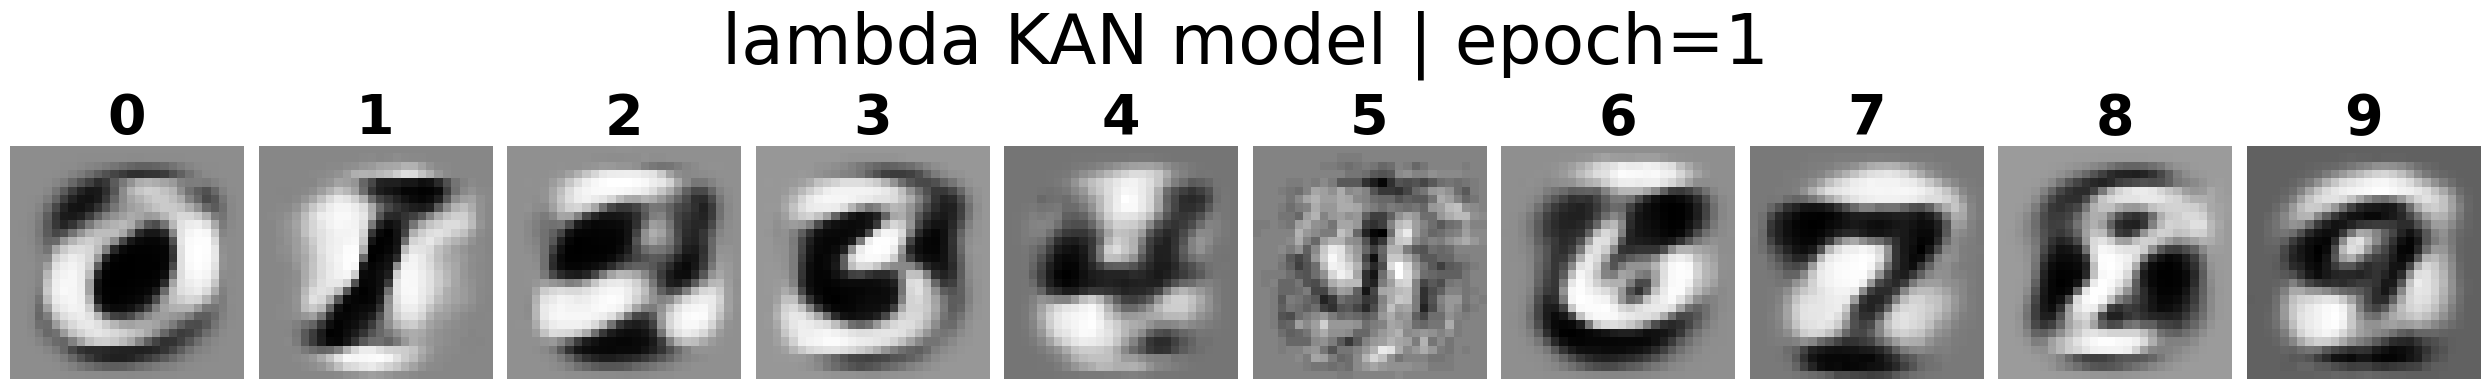

Epoch 1: 100%|██████████| 196/196 [00:25<00:00,  7.83it/s, v_num=0, loss=0.959]Shape with bias: (784, 10)


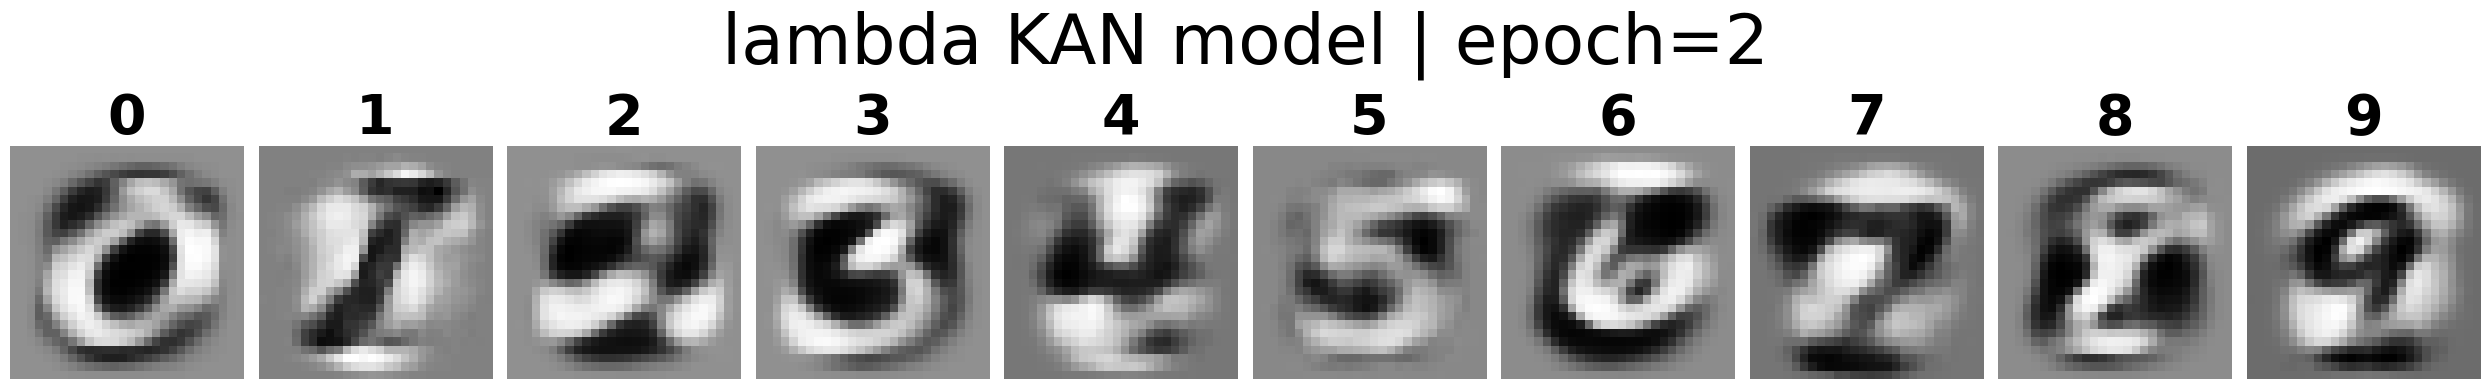

Epoch 2: 100%|██████████| 196/196 [00:25<00:00,  7.82it/s, v_num=0, loss=0.866]Shape with bias: (784, 10)


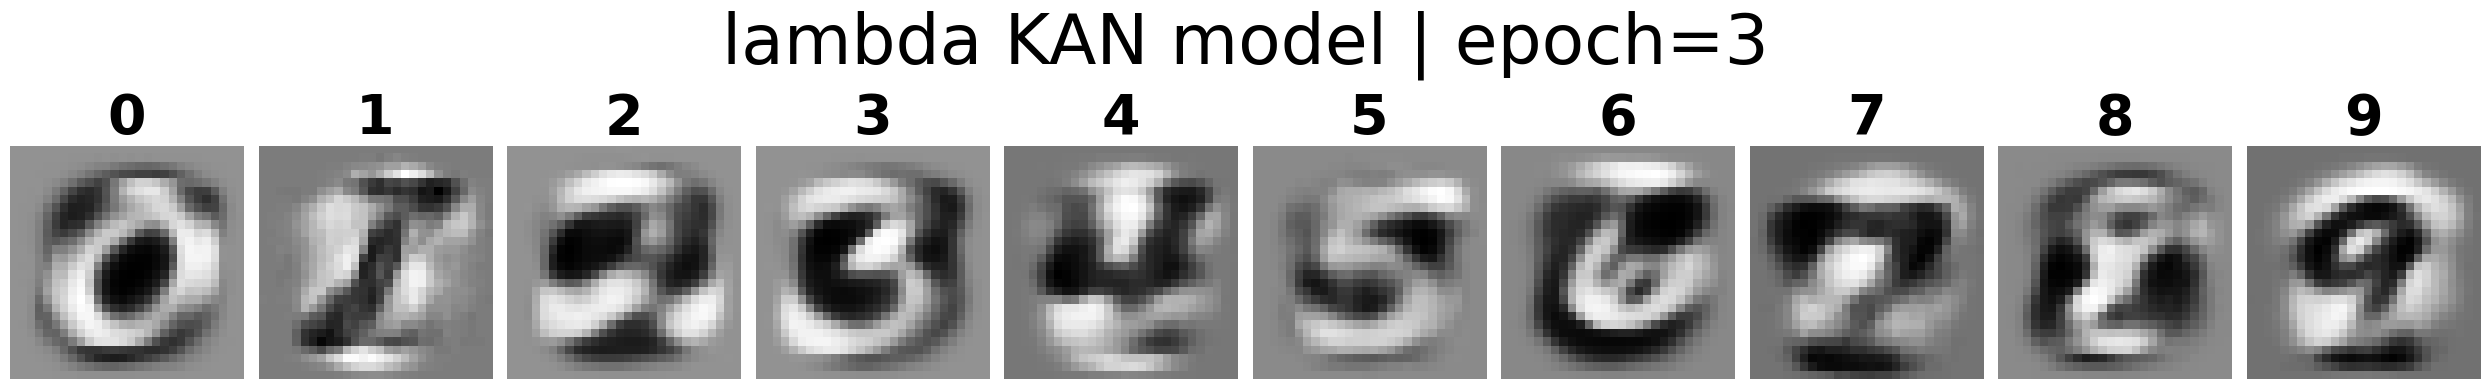

Epoch 3: 100%|██████████| 196/196 [00:25<00:00,  7.82it/s, v_num=0, loss=0.731]Shape with bias: (784, 10)


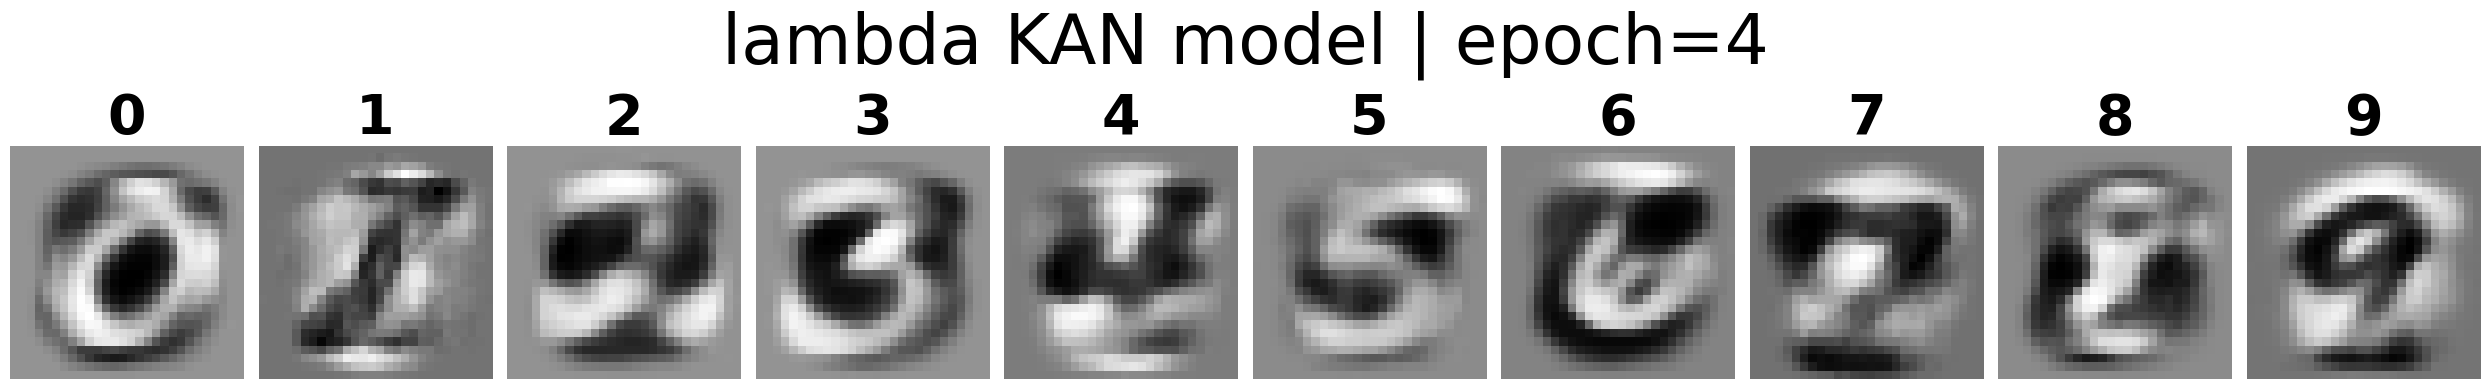

Epoch 0: 100%|██████████| 196/196 [29:40<00:00,  0.11it/s, v_num=0, loss=0.308]


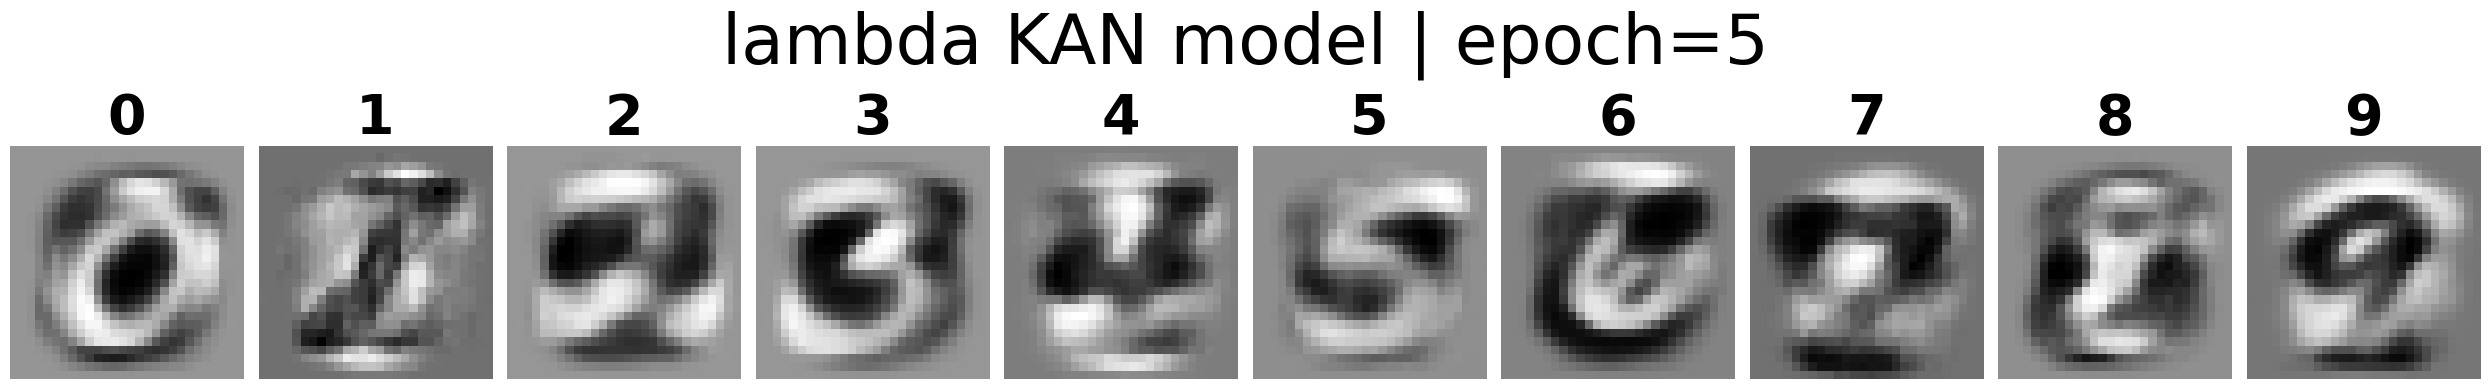

Epoch 5: 100%|██████████| 196/196 [00:25<00:00,  7.83it/s, v_num=0, loss=0.716]Shape with bias: (784, 10)


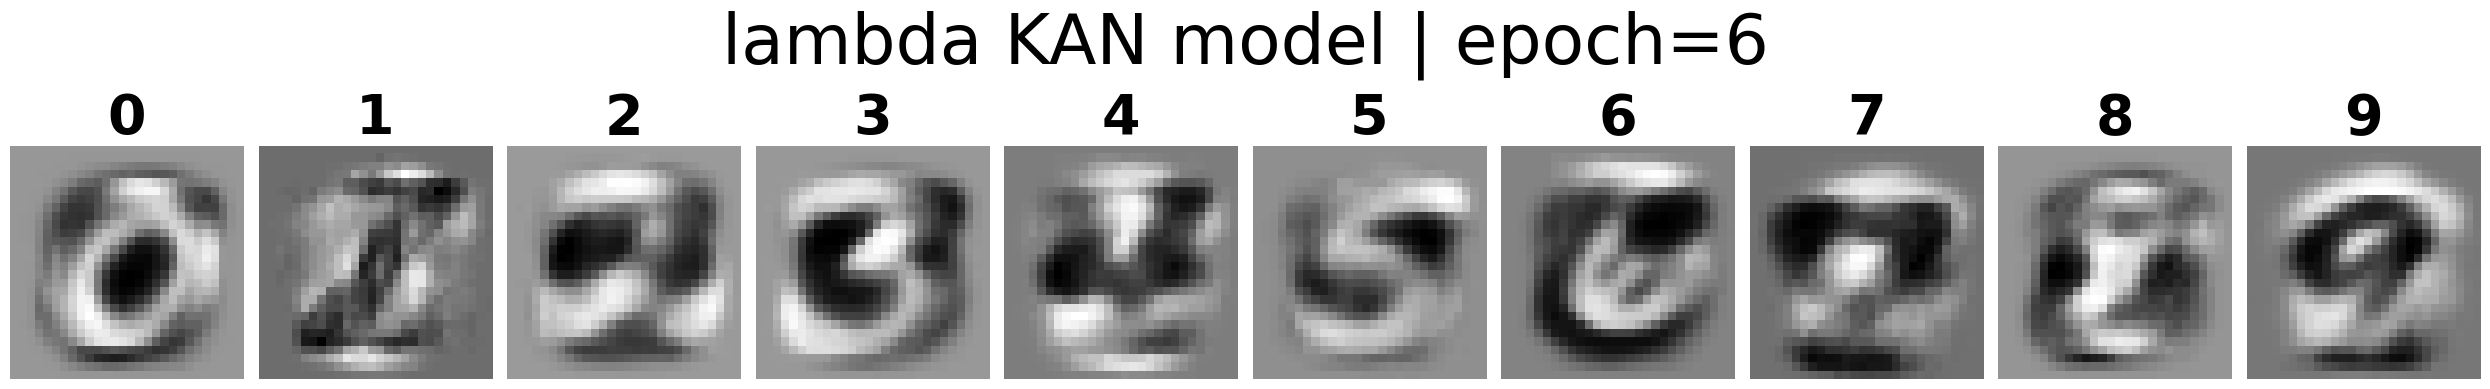

Epoch 6: 100%|██████████| 196/196 [00:25<00:00,  7.82it/s, v_num=0, loss=0.513]Shape with bias: (784, 10)


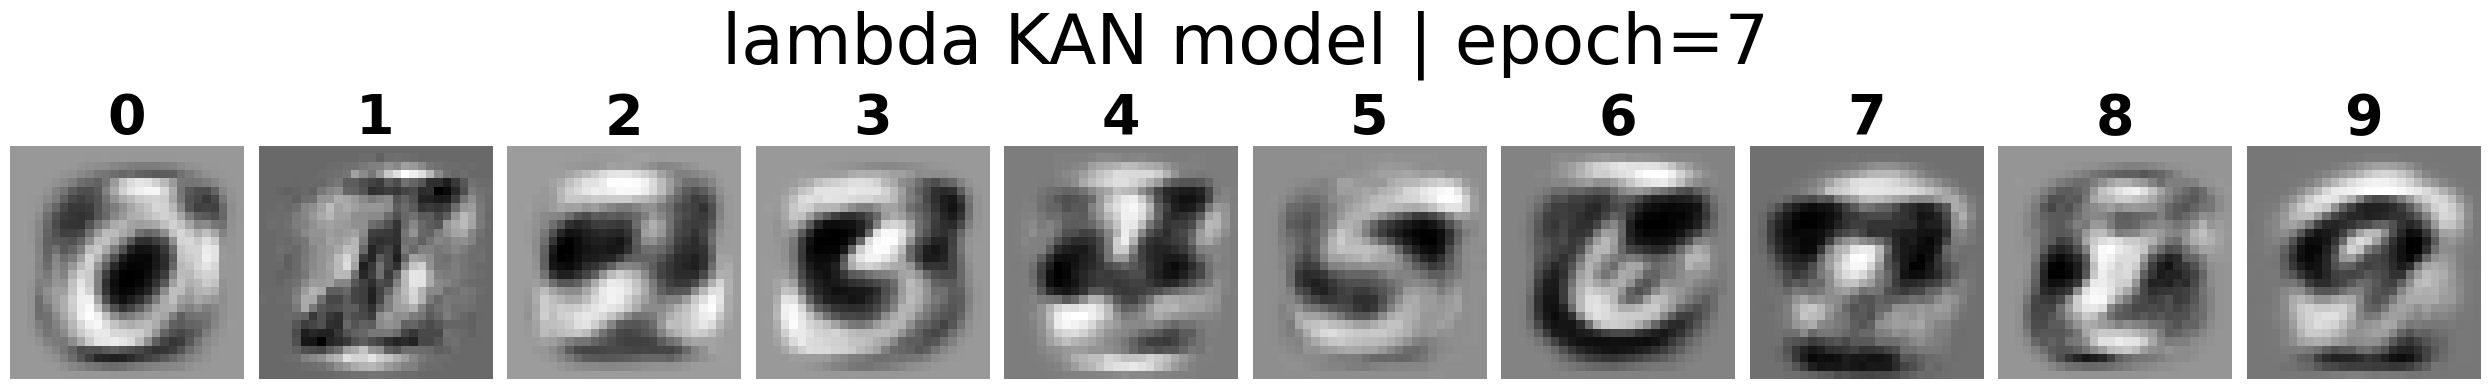

Epoch 7: 100%|██████████| 196/196 [00:25<00:00,  7.82it/s, v_num=0, loss=0.458]Shape with bias: (784, 10)


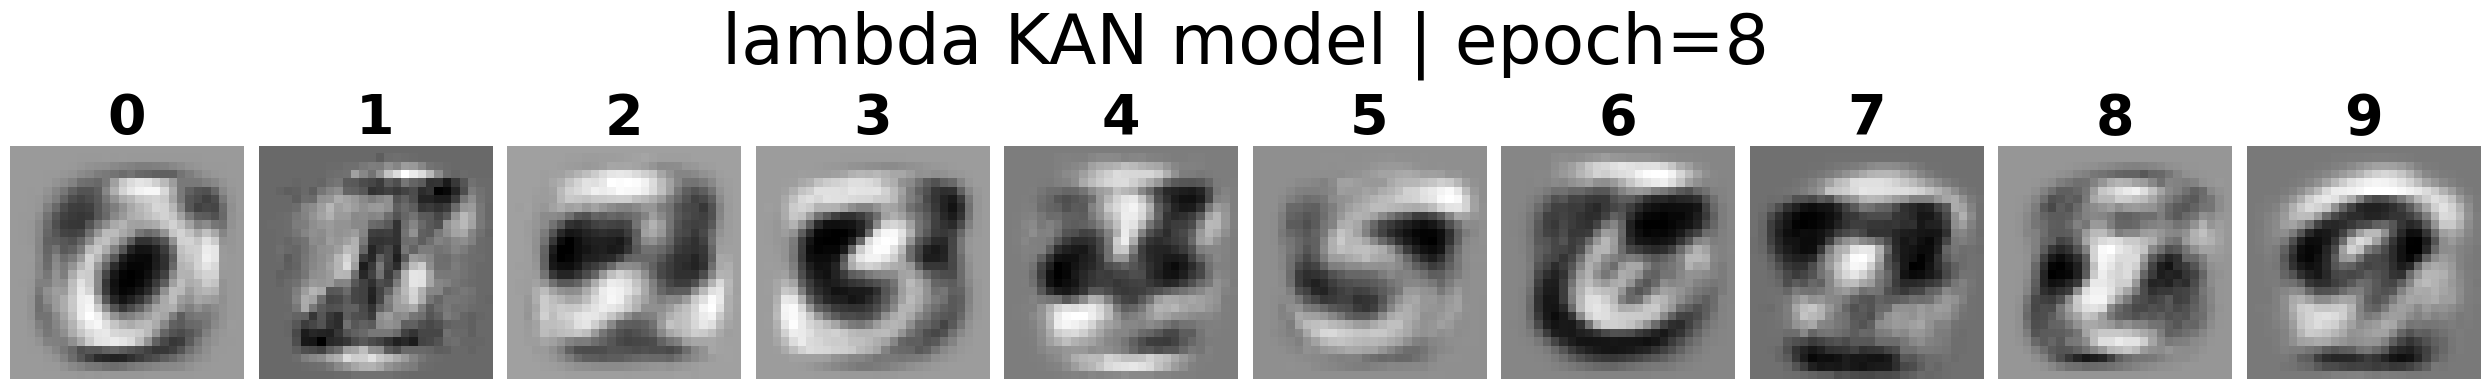

Epoch 8: 100%|██████████| 196/196 [00:25<00:00,  7.81it/s, v_num=0, loss=0.569]Shape with bias: (784, 10)


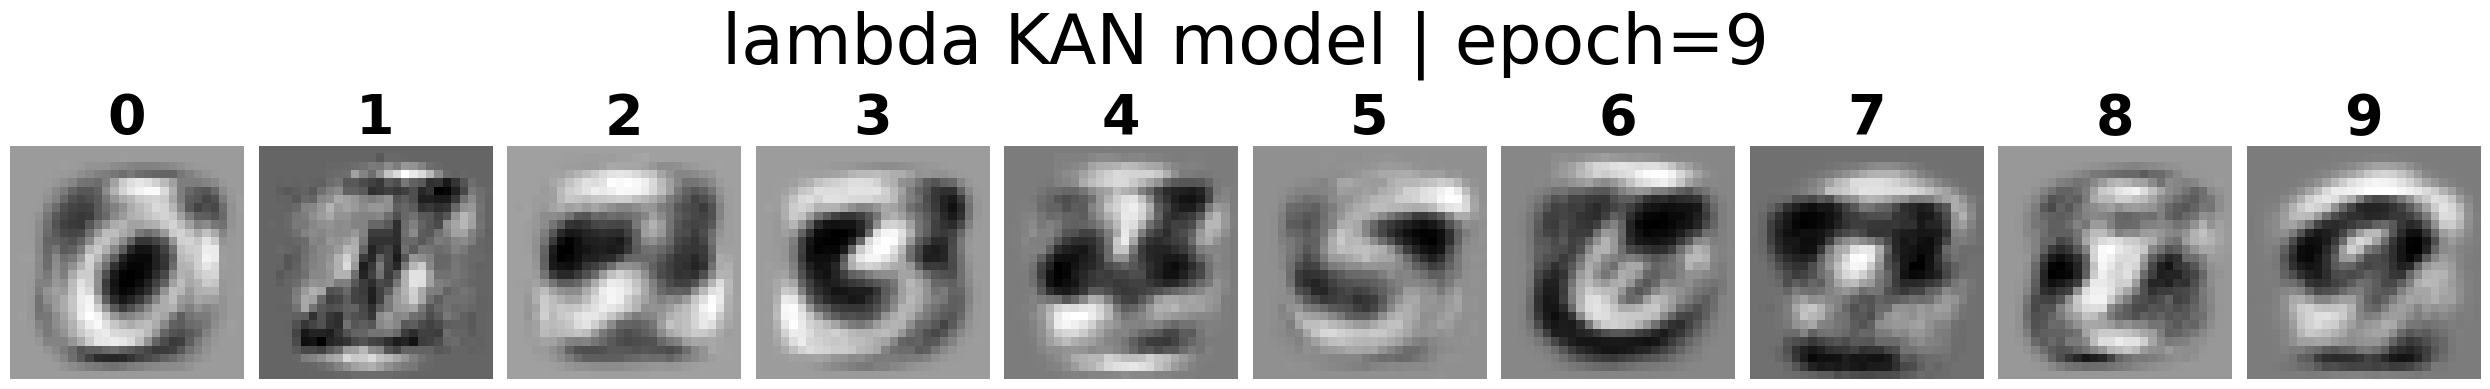

Epoch 9: 100%|██████████| 196/196 [00:25<00:00,  7.81it/s, v_num=0, loss=0.610]Shape with bias: (784, 10)


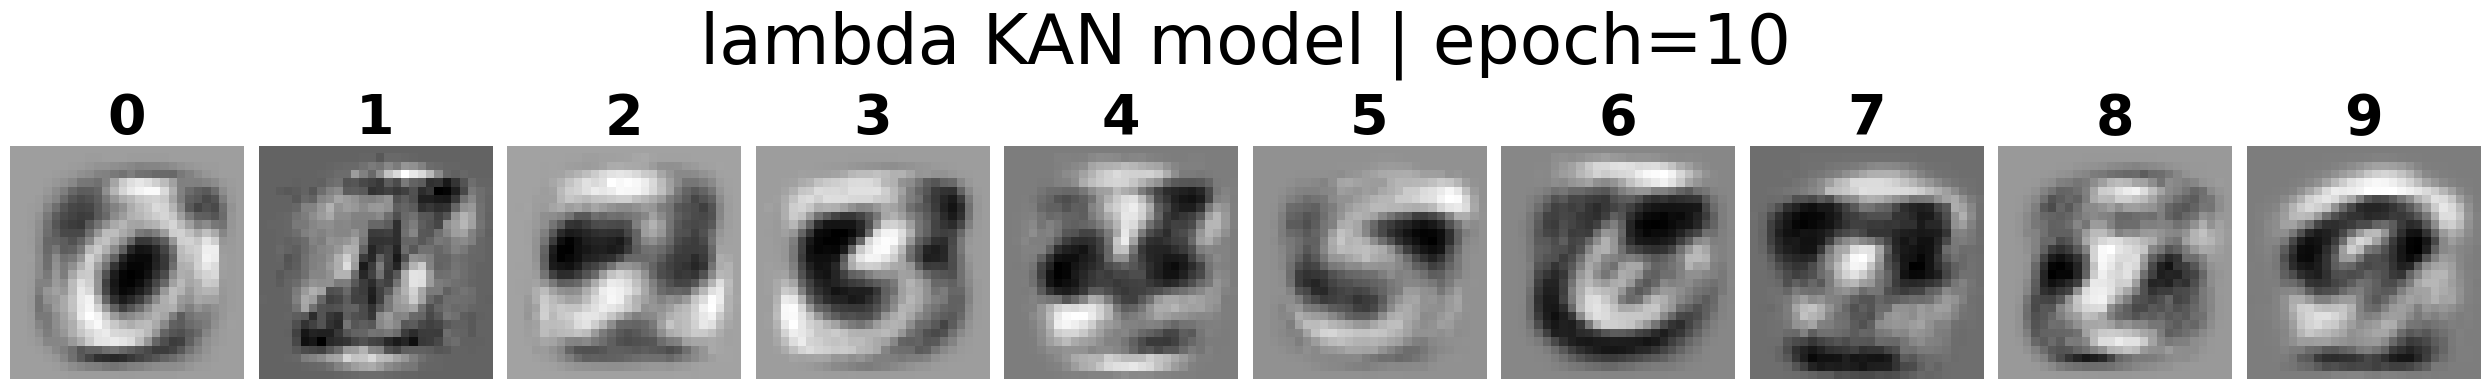

Epoch 10: 100%|██████████| 196/196 [00:25<00:00,  7.82it/s, v_num=0, loss=0.495]Shape with bias: (784, 10)


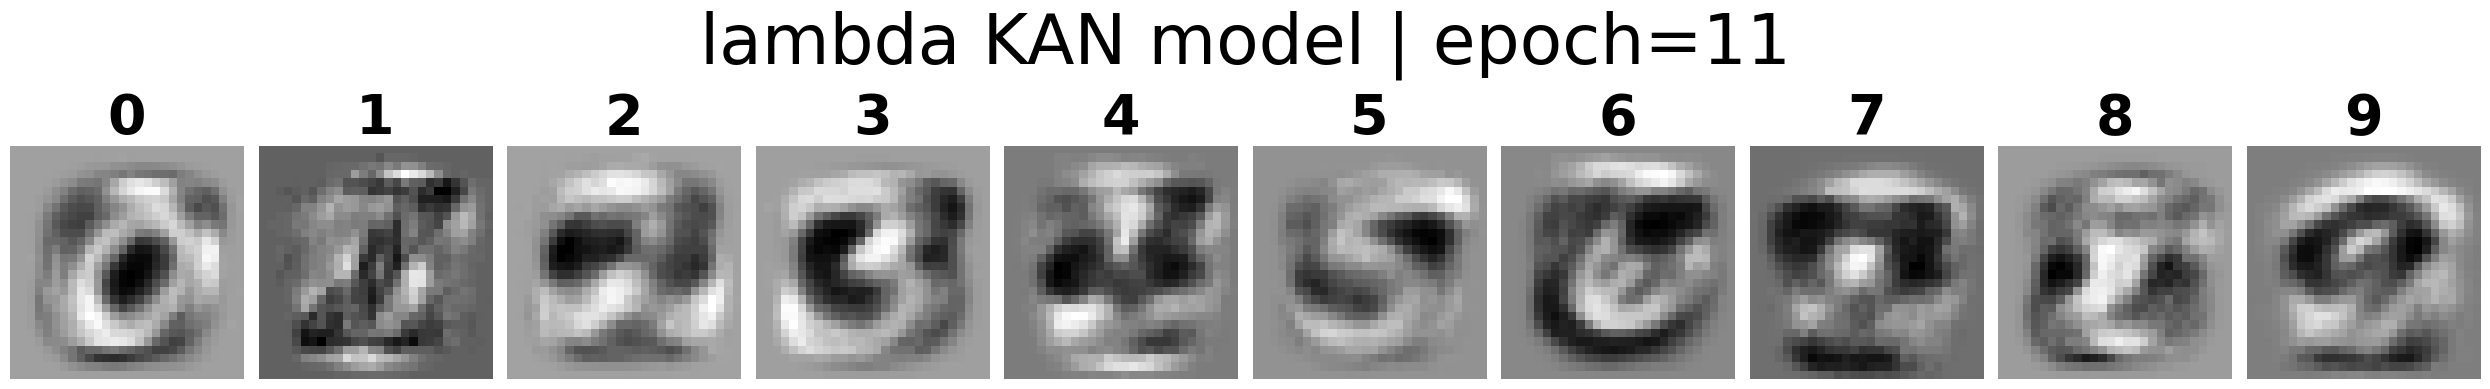

Epoch 11: 100%|██████████| 196/196 [00:25<00:00,  7.82it/s, v_num=0, loss=0.414]Shape with bias: (784, 10)


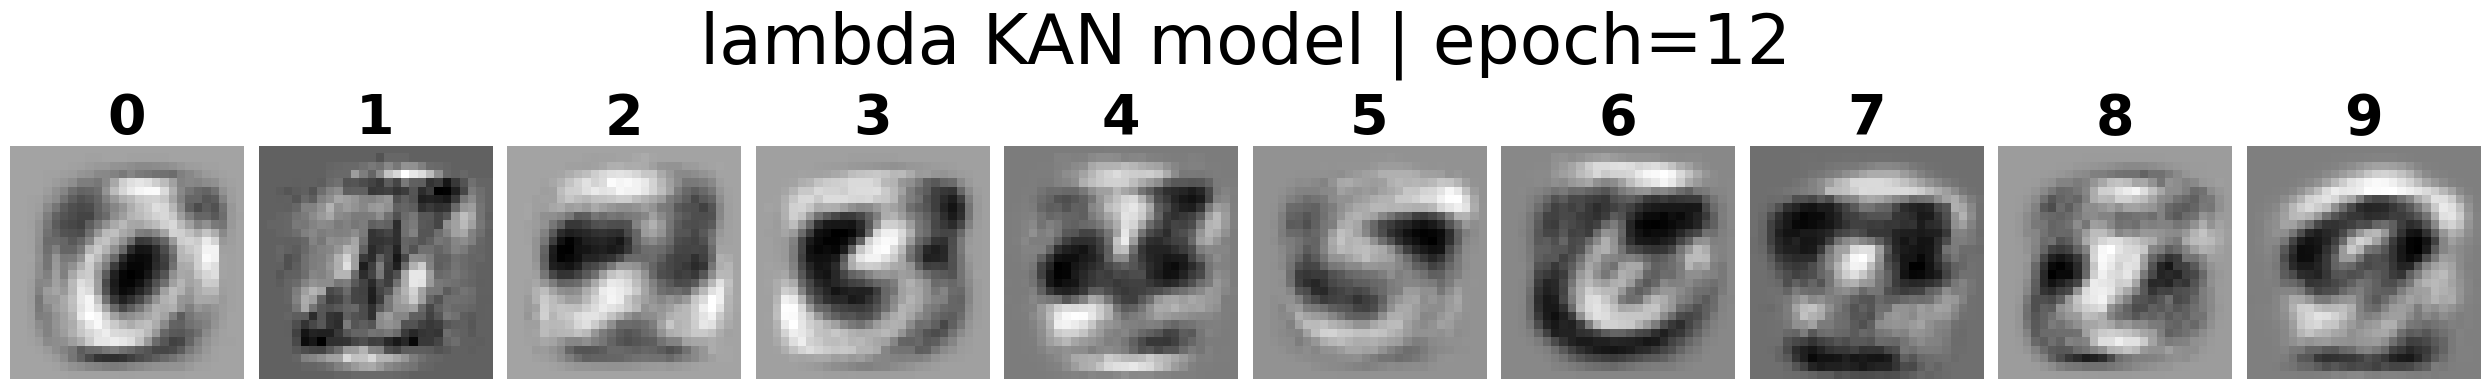

Epoch 12: 100%|██████████| 196/196 [00:25<00:00,  7.81it/s, v_num=0, loss=0.350]Shape with bias: (784, 10)


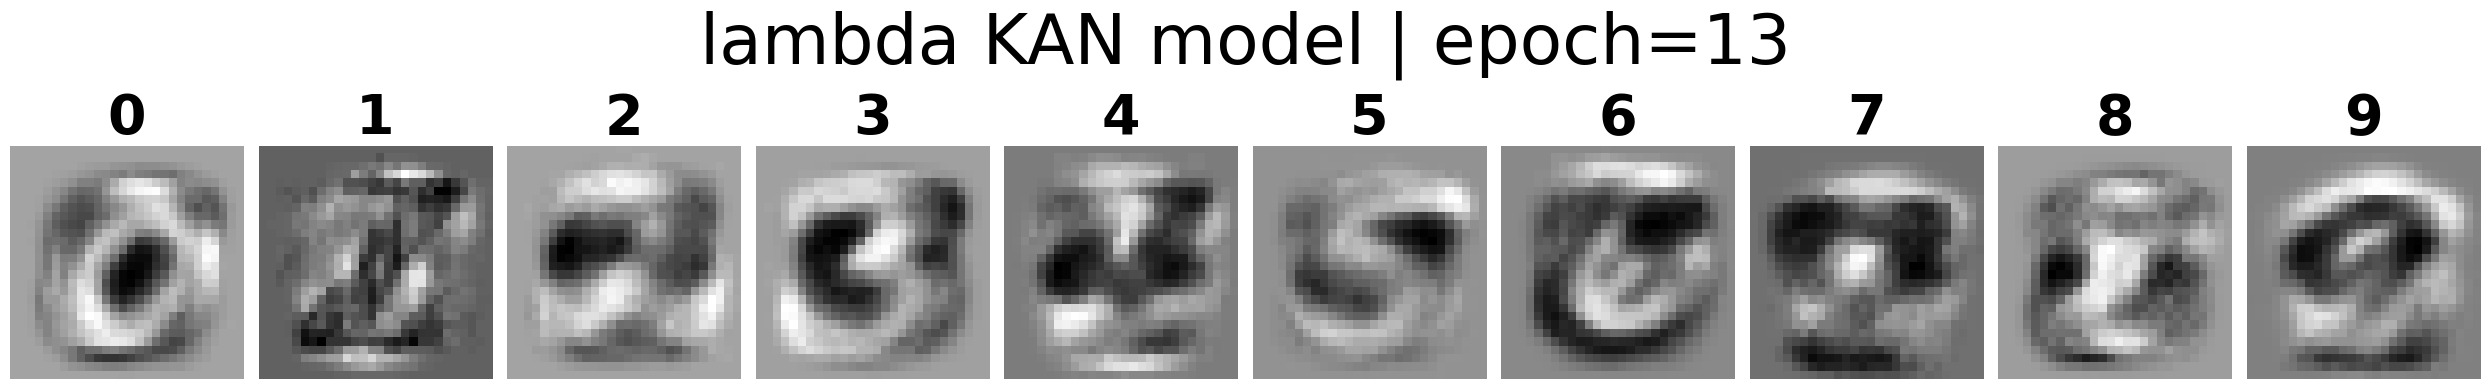

Epoch 13: 100%|██████████| 196/196 [00:25<00:00,  7.82it/s, v_num=0, loss=0.480]Shape with bias: (784, 10)


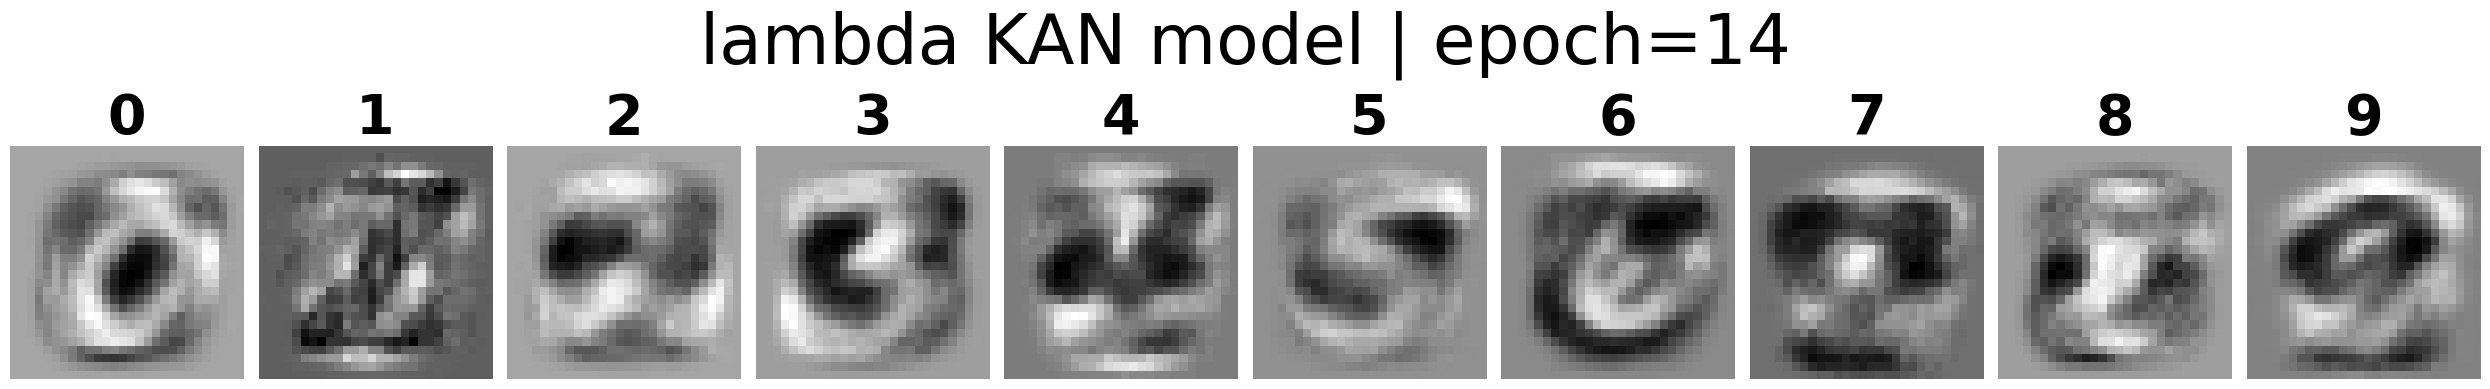

Epoch 14: 100%|██████████| 196/196 [00:25<00:00,  7.81it/s, v_num=0, loss=0.522]Shape with bias: (784, 10)


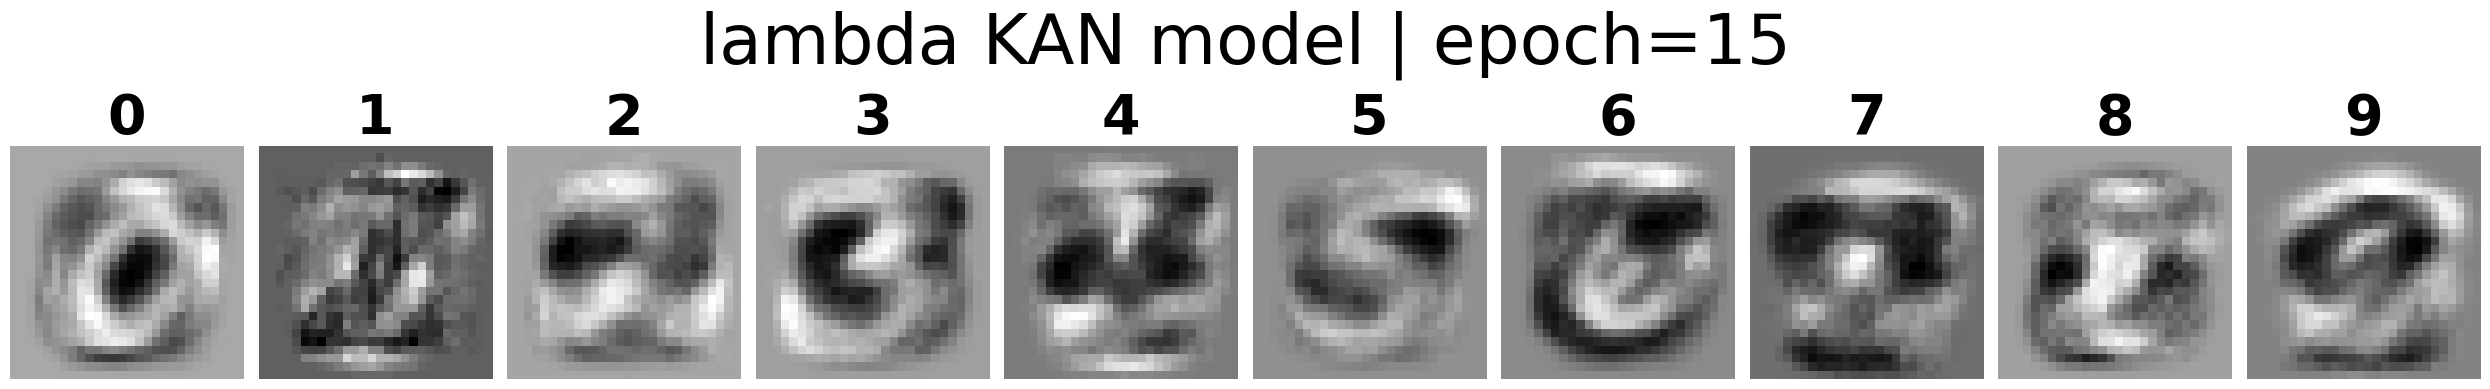

Epoch 15: 100%|██████████| 196/196 [00:25<00:00,  7.80it/s, v_num=0, loss=0.397]Shape with bias: (784, 10)


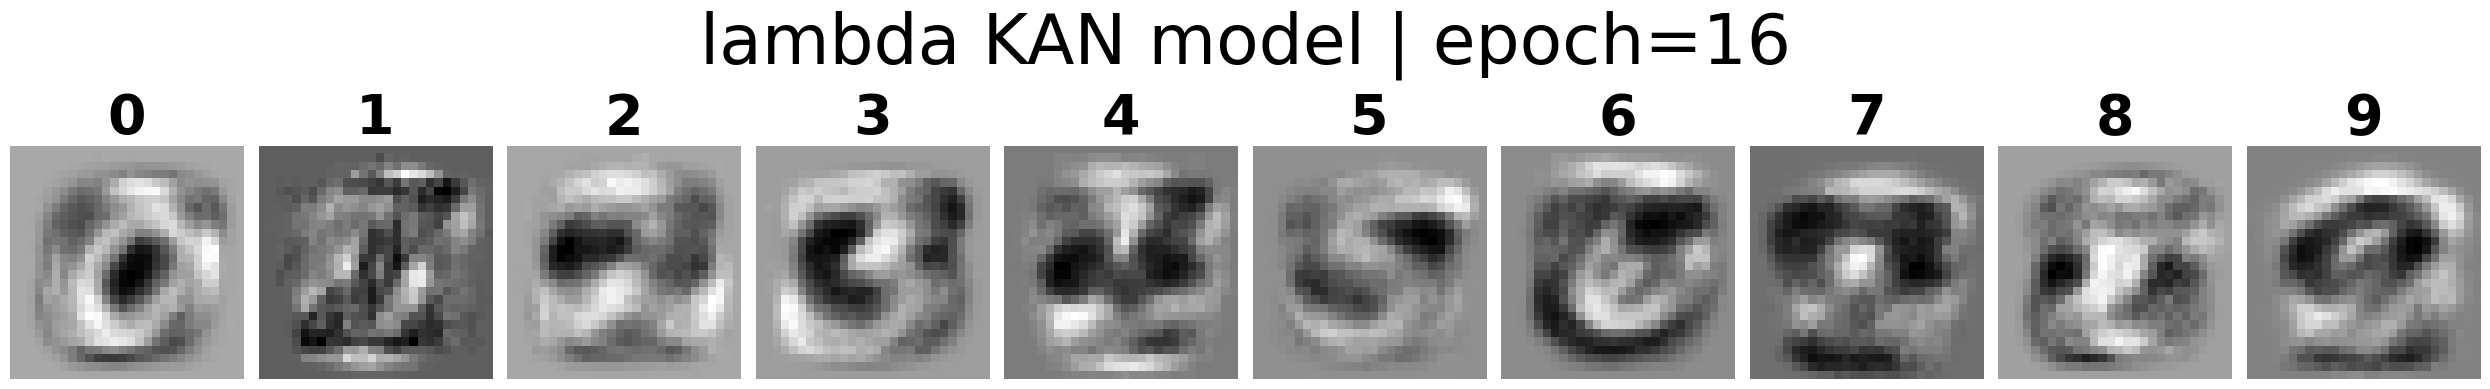

Epoch 16: 100%|██████████| 196/196 [00:25<00:00,  7.79it/s, v_num=0, loss=0.340]Shape with bias: (784, 10)


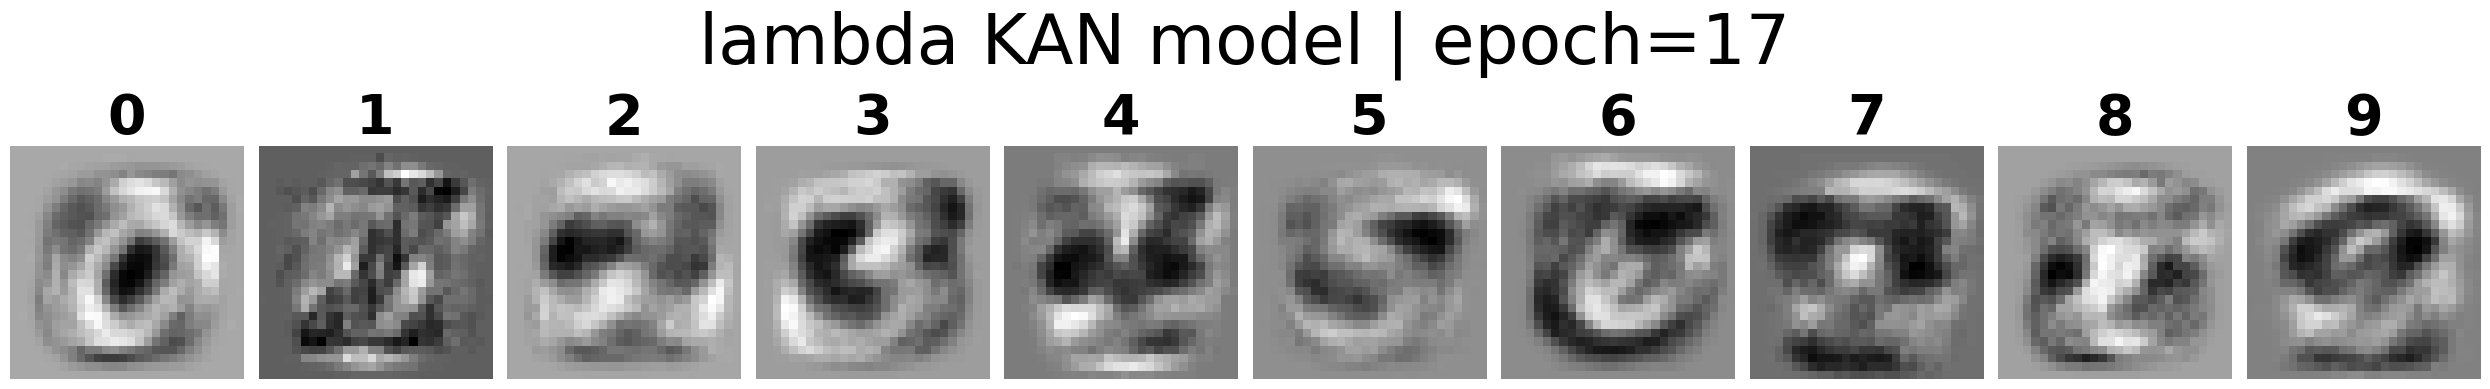

Epoch 17: 100%|██████████| 196/196 [00:25<00:00,  7.79it/s, v_num=0, loss=0.545]Shape with bias: (784, 10)


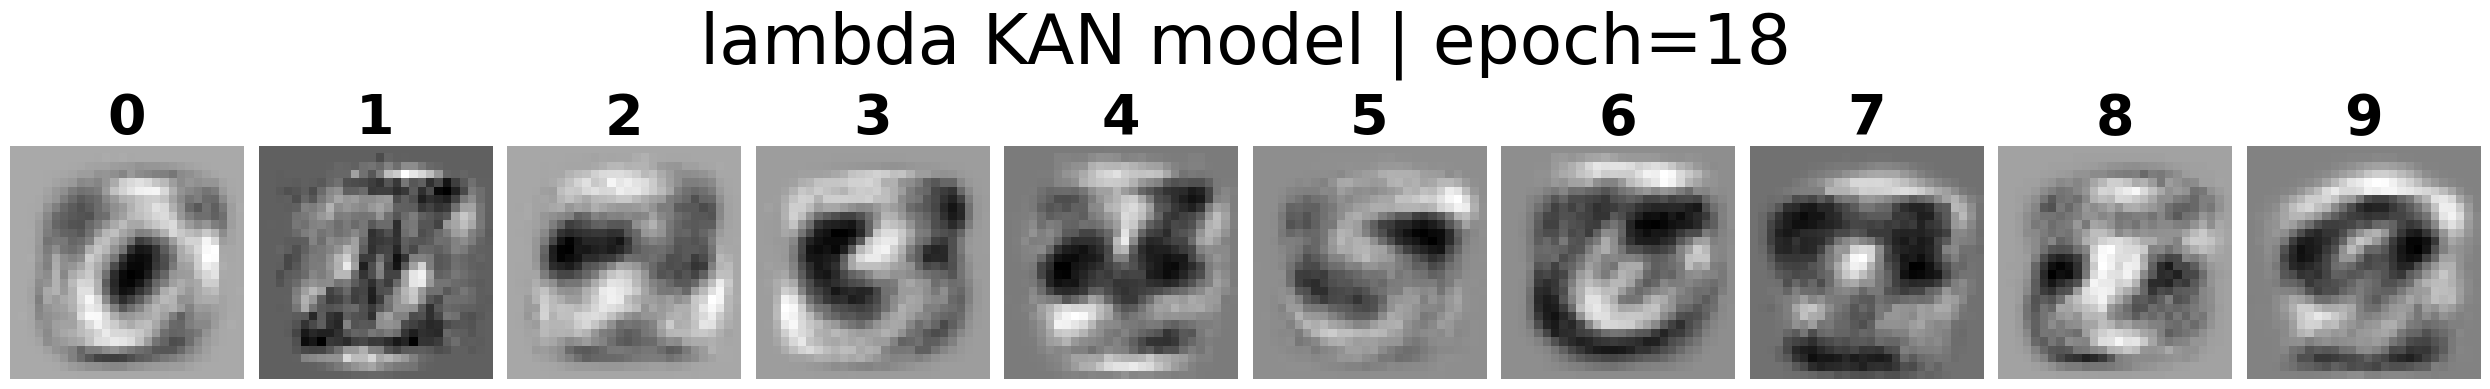

Epoch 18: 100%|██████████| 196/196 [00:25<00:00,  7.78it/s, v_num=0, loss=0.267]Shape with bias: (784, 10)


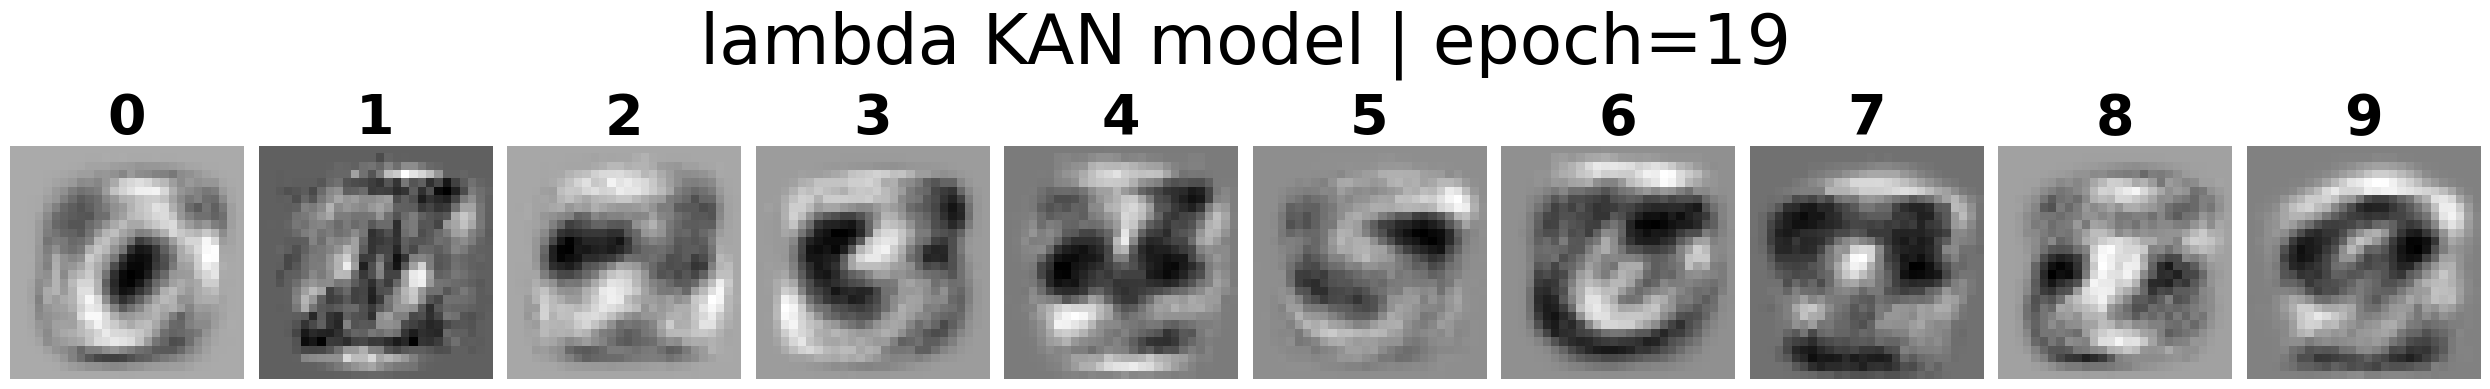

Epoch 19: 100%|██████████| 196/196 [00:25<00:00,  7.77it/s, v_num=0, loss=0.303]Shape with bias: (784, 10)


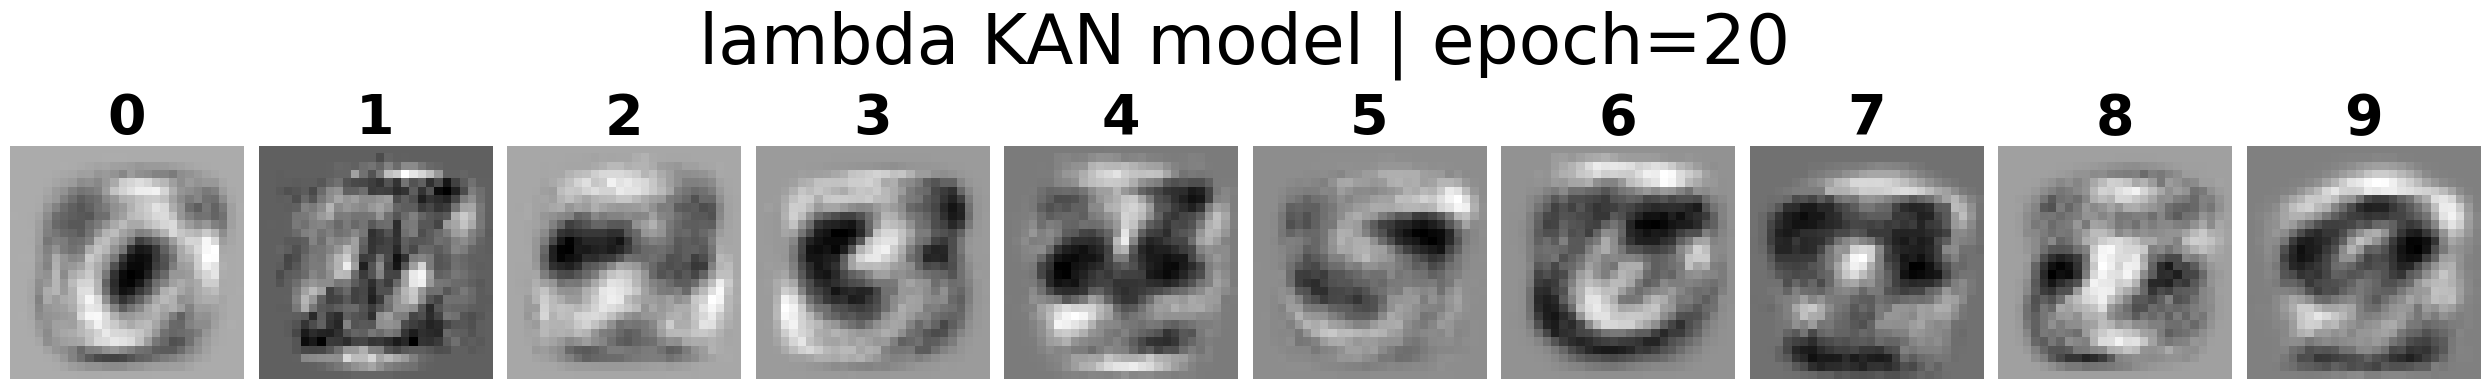

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 196/196 [00:25<00:00,  7.60it/s, v_num=0, loss=0.303]


In [ ]:
class LModel_save_pic(LModel):
    def on_train_epoch_end(self):
        self.log_dict(self.train_metrics.compute())
        self.train_metrics.reset()
        
        val_metrics = self.val_metrics.compute()
        self.log_dict(val_metrics)
        self.val_metrics.reset()
        
        directory = self.logger.log_dir + '\\sens_pic'
        if not os.path.exists(directory):
            os.makedirs(directory)
        show_sensitivity(W = self.model.get_W(),
                         title = f'lambda KAN model | epoch={self.current_epoch+1}',
                         save_pic=True, 
                         file_path=directory + f'\\{self.current_epoch}.png')


checkpoint_callback = ModelCheckpoint(
    # dirpath='best_ckp/'
    save_last=True,
    every_n_epochs=1,
    save_top_k=1,
    save_weights_only=True,
    monitor="MulticlassAccuracy/val",
    filename="model",
    mode="max",
)

L.seed_everything(1755)

model = Mnist_lmdSplineKAN() #Mnist_lmdSplineKAN() #MnistPrllSplineKAN() #MnistSplineKAN() #MnistSplineKAN() #MnistKAN() #MnistMLP() #MnistCNN() #MnistLR()
pl_model = LModel_save_pic(model)
trainer = L.Trainer(
    max_epochs=20,
    callbacks=[checkpoint_callback],
    num_sanity_val_steps=0,
    log_every_n_steps=10,
    logger=L.pytorch.loggers.TensorBoardLogger(save_dir=f"./logs/{type(model).__name__}/"),
)

trainer.fit(
    model=pl_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

In [11]:
# Load the best checkpoint automatically (lightning tracks this for you)
trainer.test(
    model=pl_model, dataloaders=test_loader, verbose=True, ckpt_path="best"
)

Restoring states from the checkpoint path at ./logs/Mnist_lmdSplineKAN/lightning_logs\version_0\checkpoints\model.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at ./logs/Mnist_lmdSplineKAN/lightning_logs\version_0\checkpoints\model.ckpt


Testing DataLoader 0: 100%|██████████| 40/40 [00:02<00:00, 13.59it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    MulticlassAccuracy     │    0.8921772241592407     │
└───────────────────────────┴───────────────────────────┘

[{'MulticlassAccuracy': 0.8921772241592407}]

In [17]:
# Параметры
model = Mnist_lmdSplineKAN()
l_seeds = [13, 14, 15, 16, 17]

# Запуск экспериментов
results_df = run_experiments_with_seeds(
    model=model,
    l_seeds=l_seeds,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    max_epochs=20,
    output_csv="stats_results/Mnist_lmdSplineKAN.csv"
)

# Просмотр результатов
print("\nТаблица результатов:")
print(results_df)

Seed set to 13
c:\Users\Gavriil\VS_projects\lambda_KAN\.venv\lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | model         | Mnist_lmdSplineKAN | 537 K  | train
1 | criterion     | CrossEntropyLoss   | 0      | train
2 | metrics       | MetricCollection   | 0      | train
3 | train_metrics | MetricCollection   | 0      | train
4 | val_metrics   | MetricCollection   | 0      | train
-------------------------------------------------------------
35.4 K    Trainable params
502 K     Non-trainable params
537 K     Total params
2.152     Total estimated model params size (MB


Запуск эксперимента с seed=13

Epoch 1:  84%|████████▍ | 165/196 [05:20<01:00,  0.51it/s, v_num=0, loss=1.310]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

#### Mnist_tlmdSplineKAN

Seed set to 1755
c:\Users\Student\VSprojects_Gavr\lambda_KAN\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | model         | Mnist_tlmdSplineKAN | 1.5 M  | 

Epoch 0: 100%|██████████| 196/196 [00:29<00:00,  6.76it/s, v_num=0, loss=0.947]Shape with bias: (784, 10)


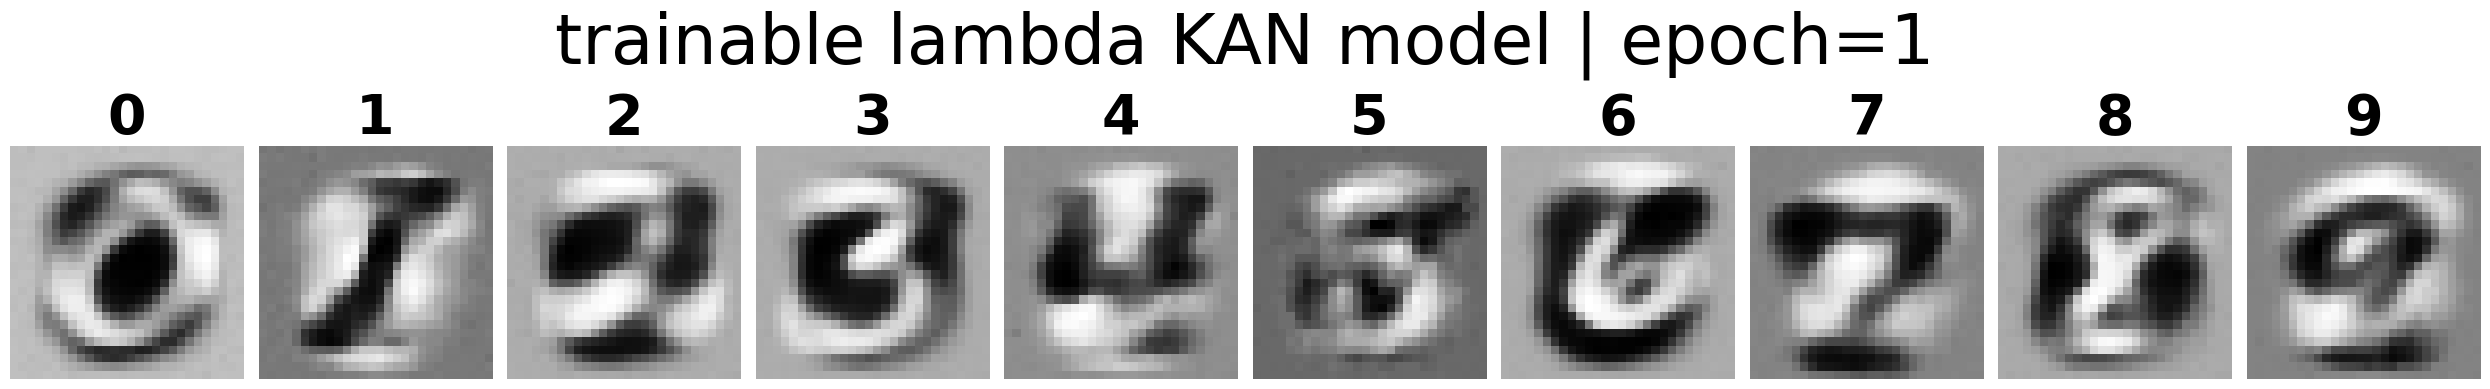

Epoch 1: 100%|██████████| 196/196 [00:25<00:00,  7.55it/s, v_num=0, loss=0.934]Shape with bias: (784, 10)


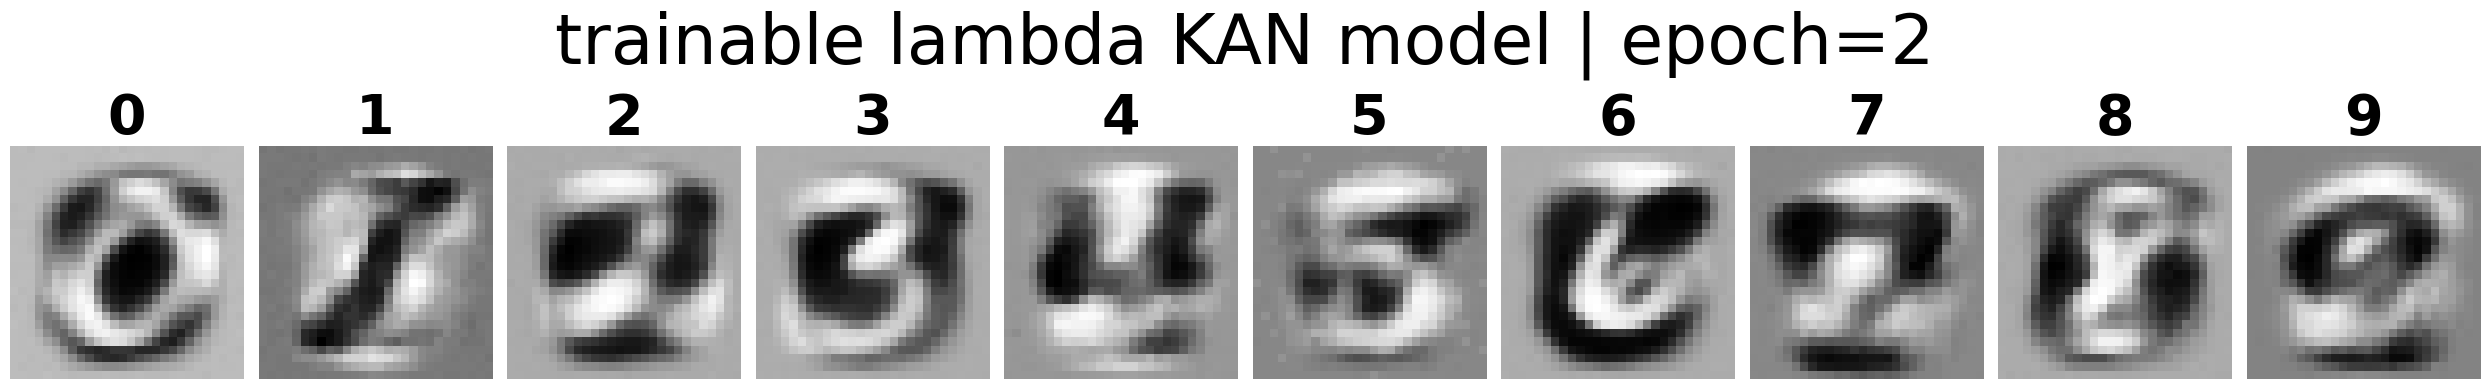

Epoch 2: 100%|██████████| 196/196 [00:25<00:00,  7.54it/s, v_num=0, loss=0.277]Shape with bias: (784, 10)


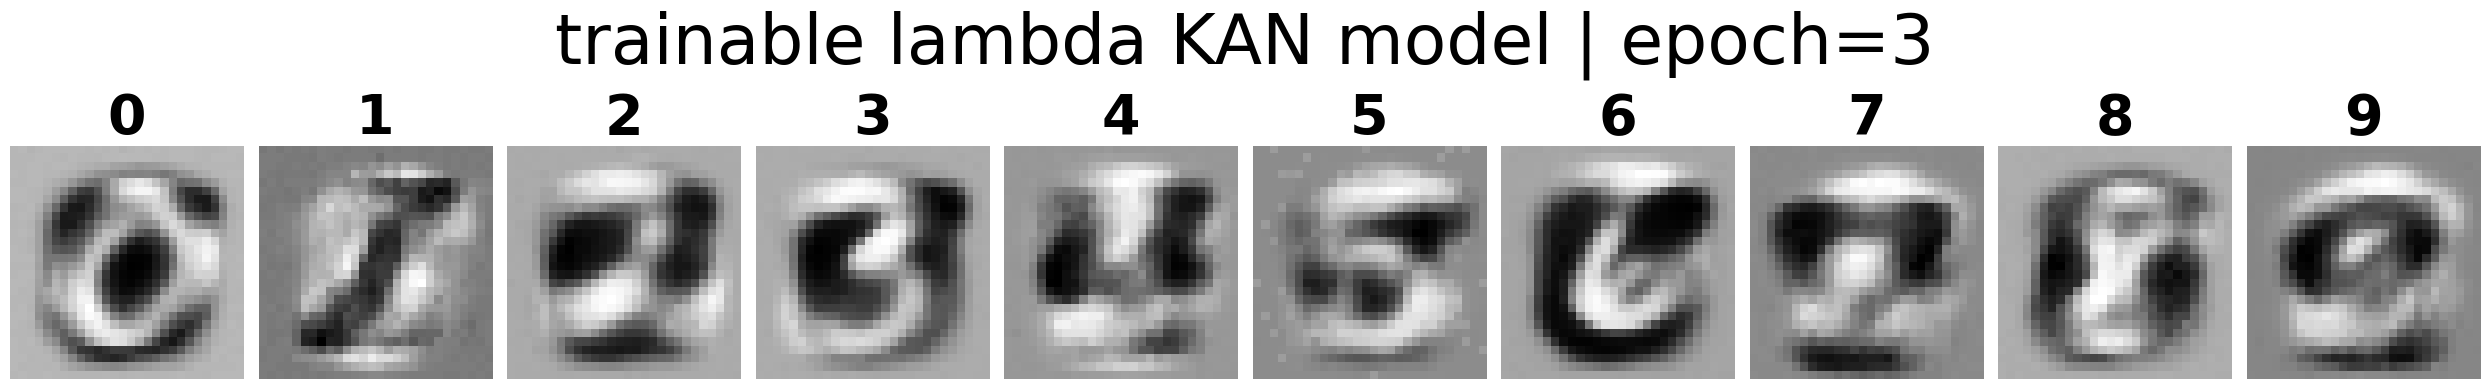

Epoch 3: 100%|██████████| 196/196 [00:25<00:00,  7.54it/s, v_num=0, loss=0.357]Shape with bias: (784, 10)


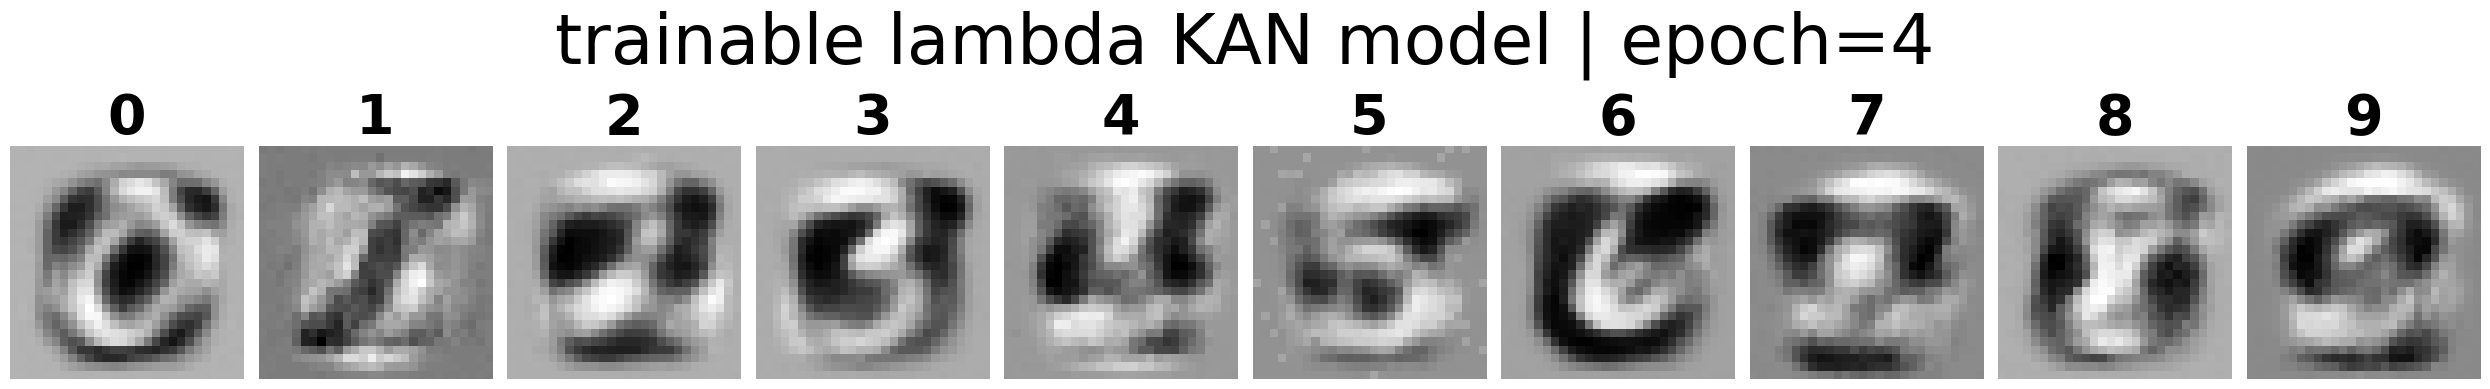

Epoch 4: 100%|██████████| 196/196 [00:25<00:00,  7.54it/s, v_num=0, loss=0.471]Shape with bias: (784, 10)


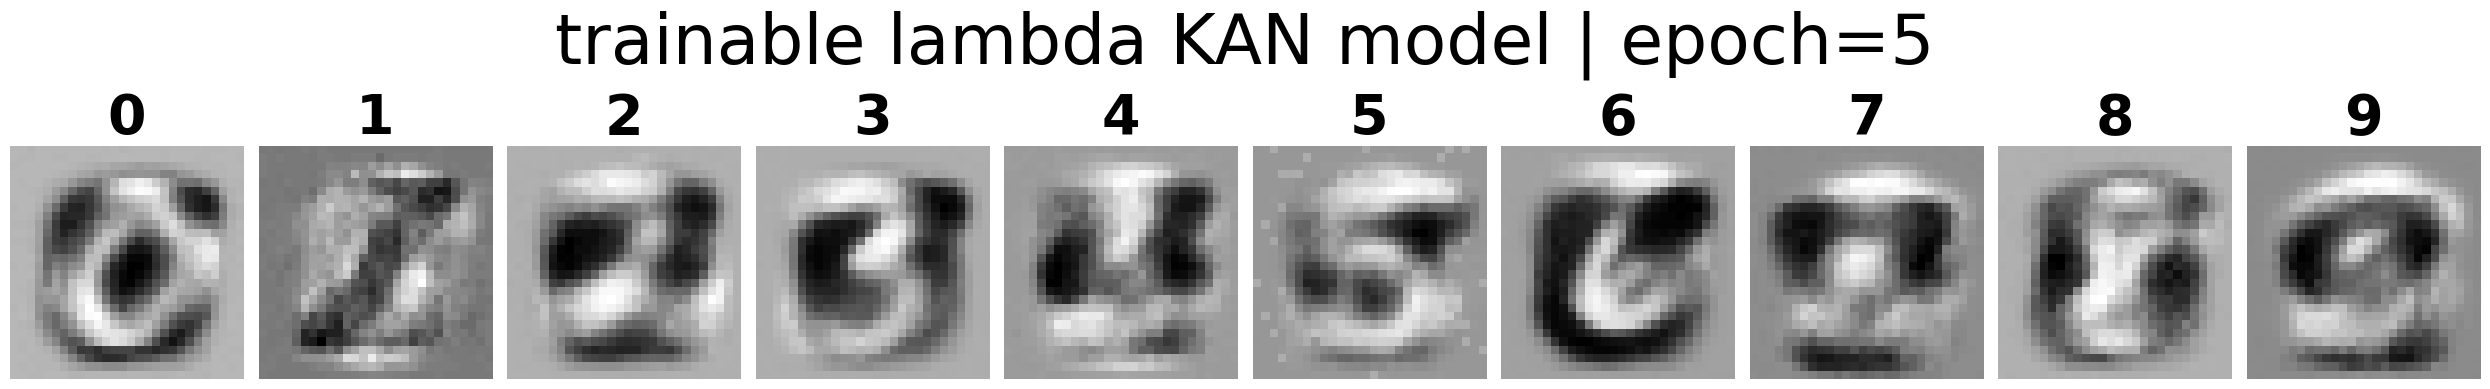

Epoch 5: 100%|██████████| 196/196 [00:25<00:00,  7.54it/s, v_num=0, loss=0.360]Shape with bias: (784, 10)


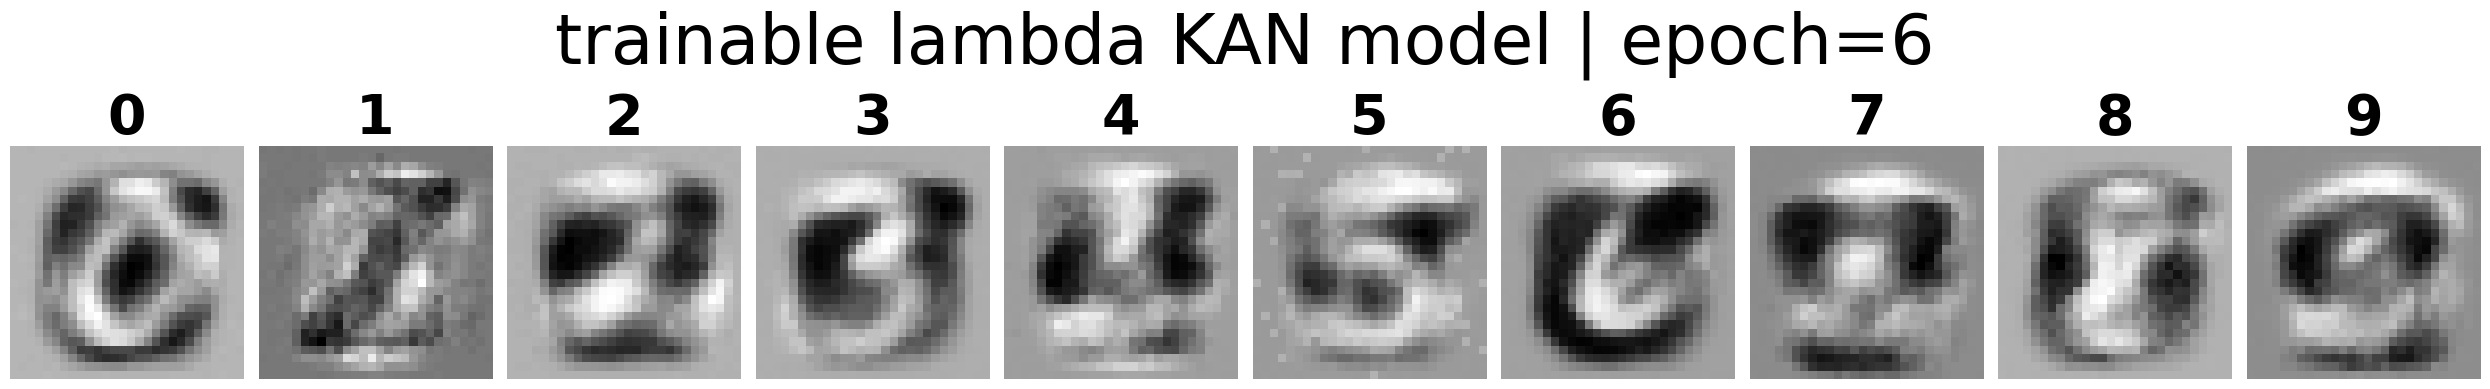

Epoch 6: 100%|██████████| 196/196 [00:25<00:00,  7.54it/s, v_num=0, loss=0.384] Shape with bias: (784, 10)


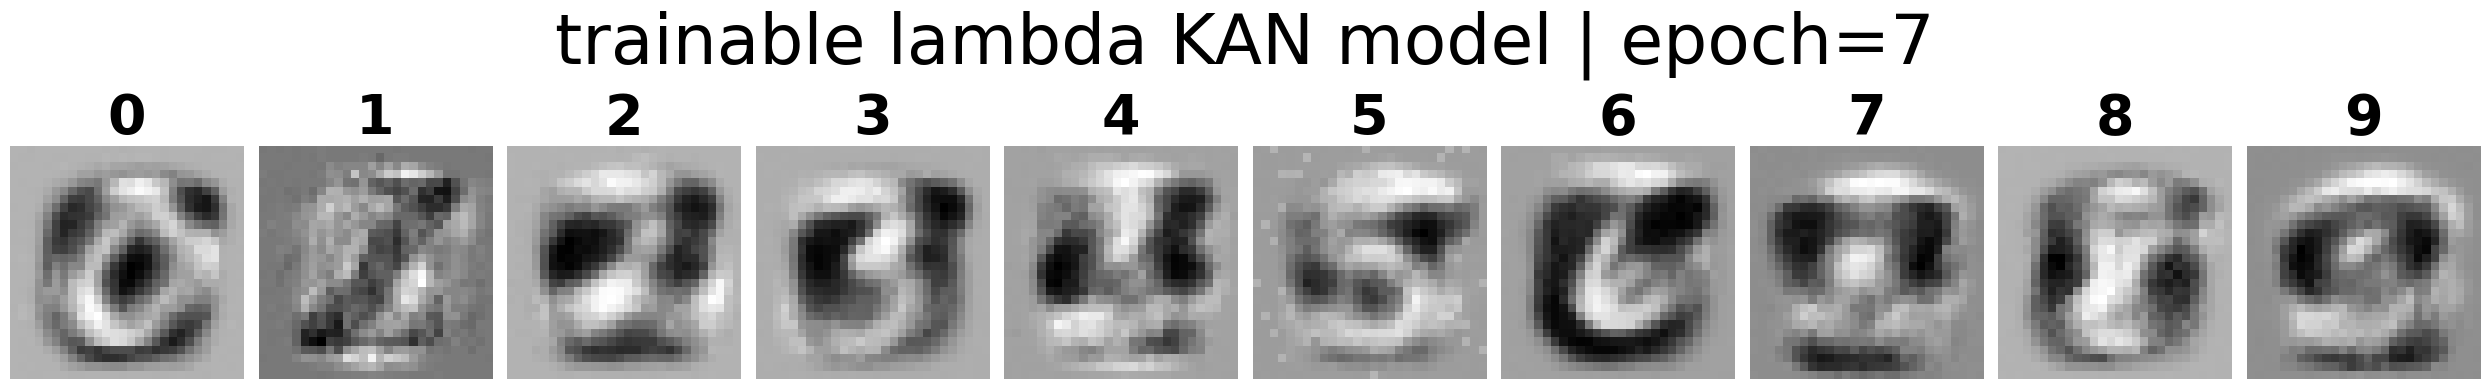

Epoch 7: 100%|██████████| 196/196 [00:26<00:00,  7.54it/s, v_num=0, loss=0.254]Shape with bias: (784, 10)


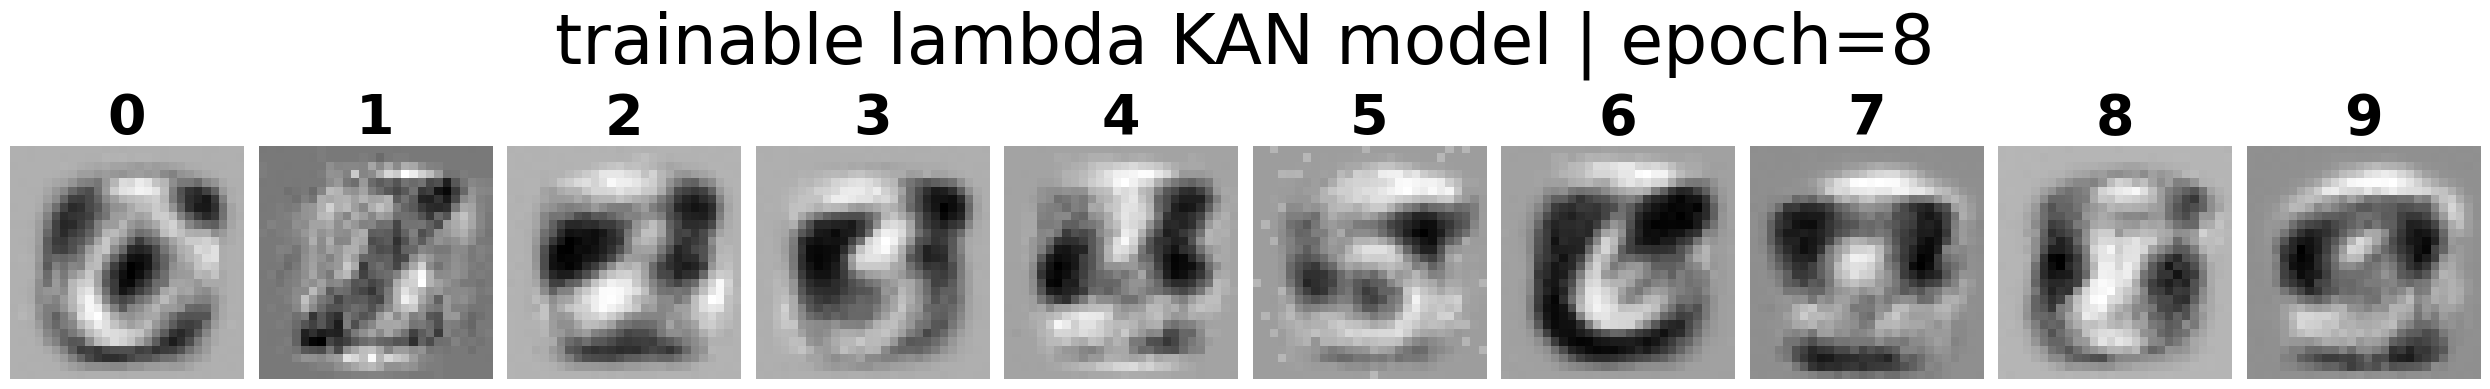

Epoch 8: 100%|██████████| 196/196 [00:26<00:00,  7.53it/s, v_num=0, loss=0.223]Shape with bias: (784, 10)


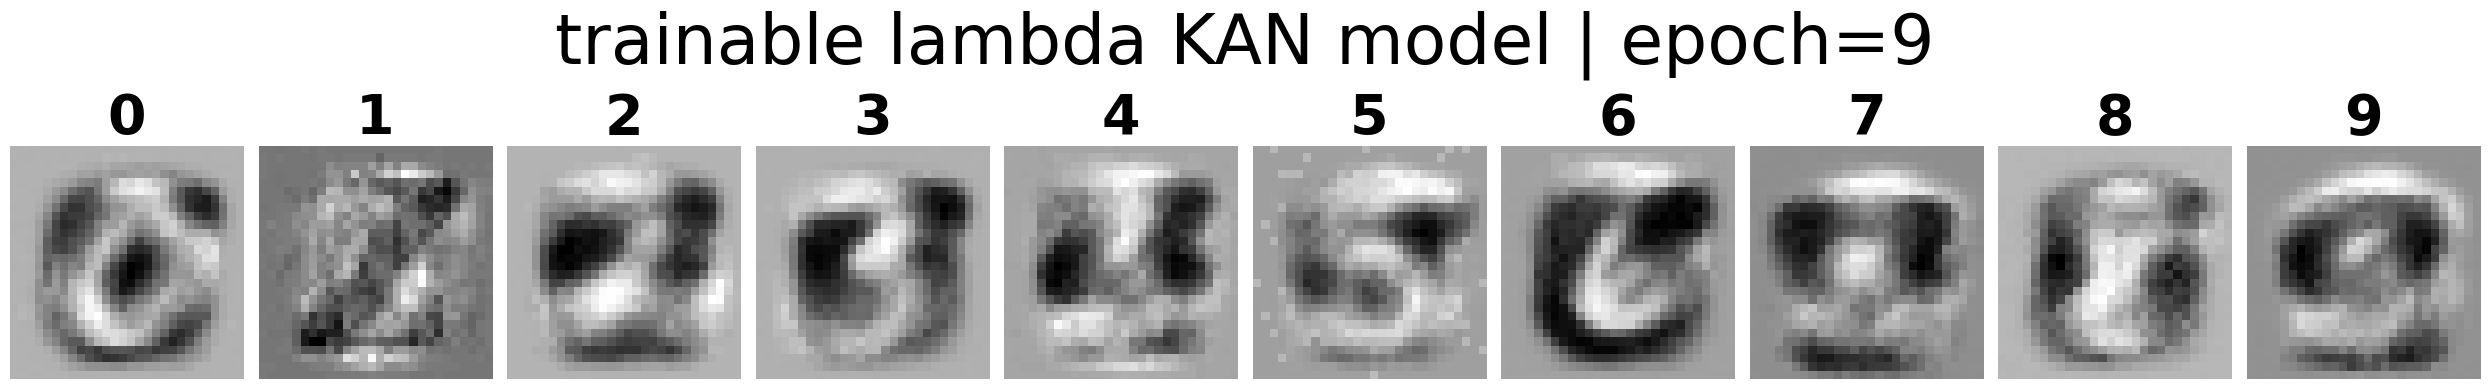

Epoch 9: 100%|██████████| 196/196 [00:25<00:00,  7.54it/s, v_num=0, loss=0.137] Shape with bias: (784, 10)


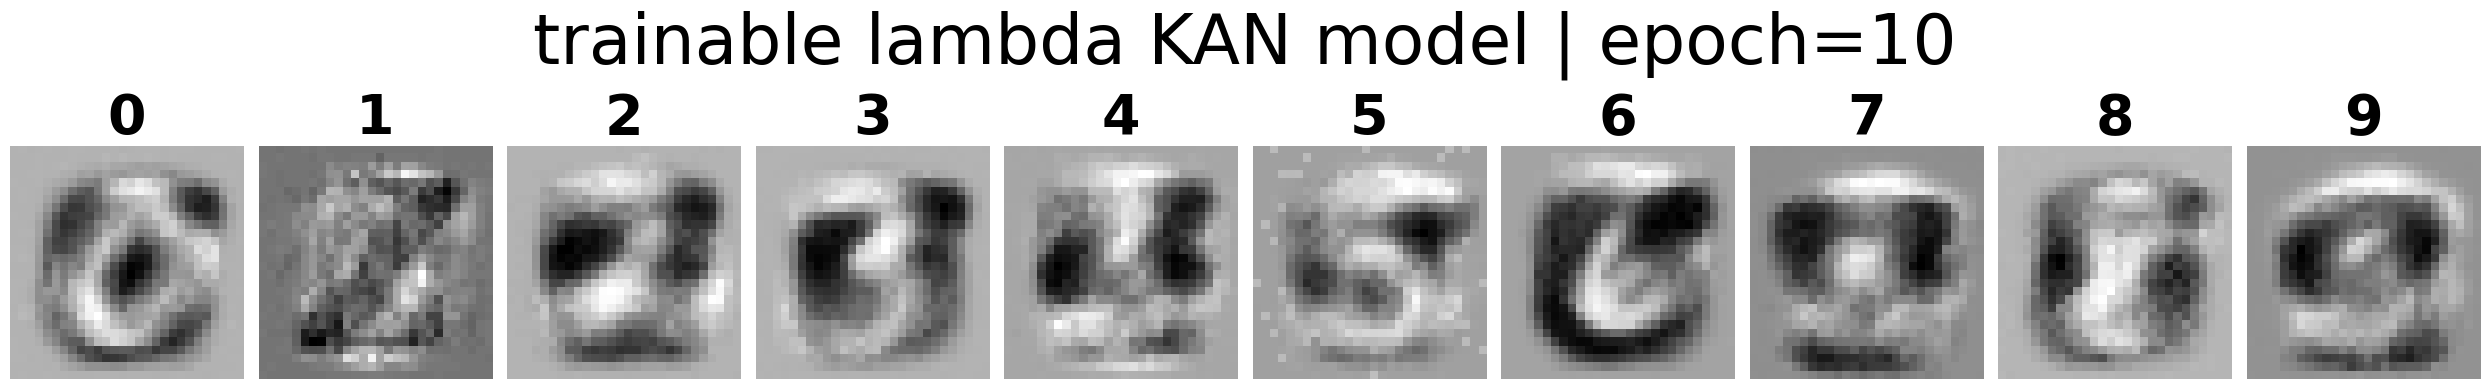

Epoch 10: 100%|██████████| 196/196 [00:26<00:00,  7.54it/s, v_num=0, loss=0.161] Shape with bias: (784, 10)


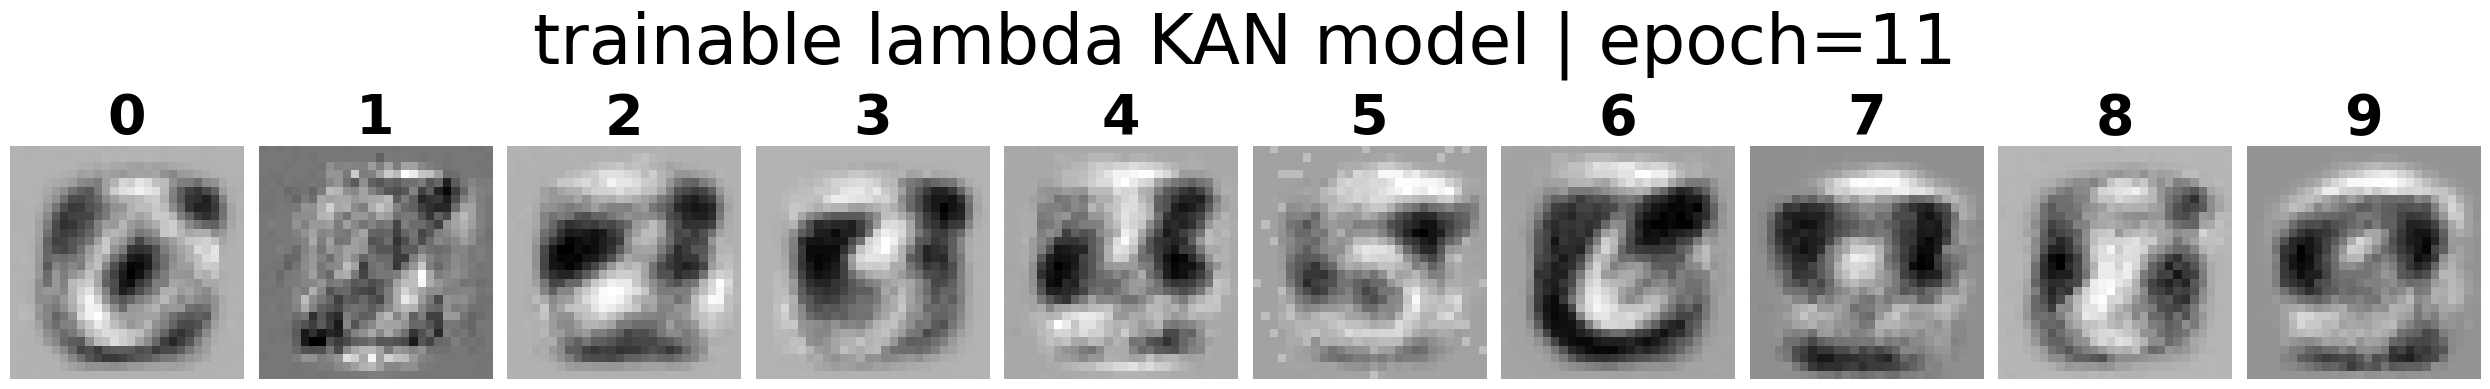

Epoch 11: 100%|██████████| 196/196 [00:26<00:00,  7.54it/s, v_num=0, loss=0.208] Shape with bias: (784, 10)


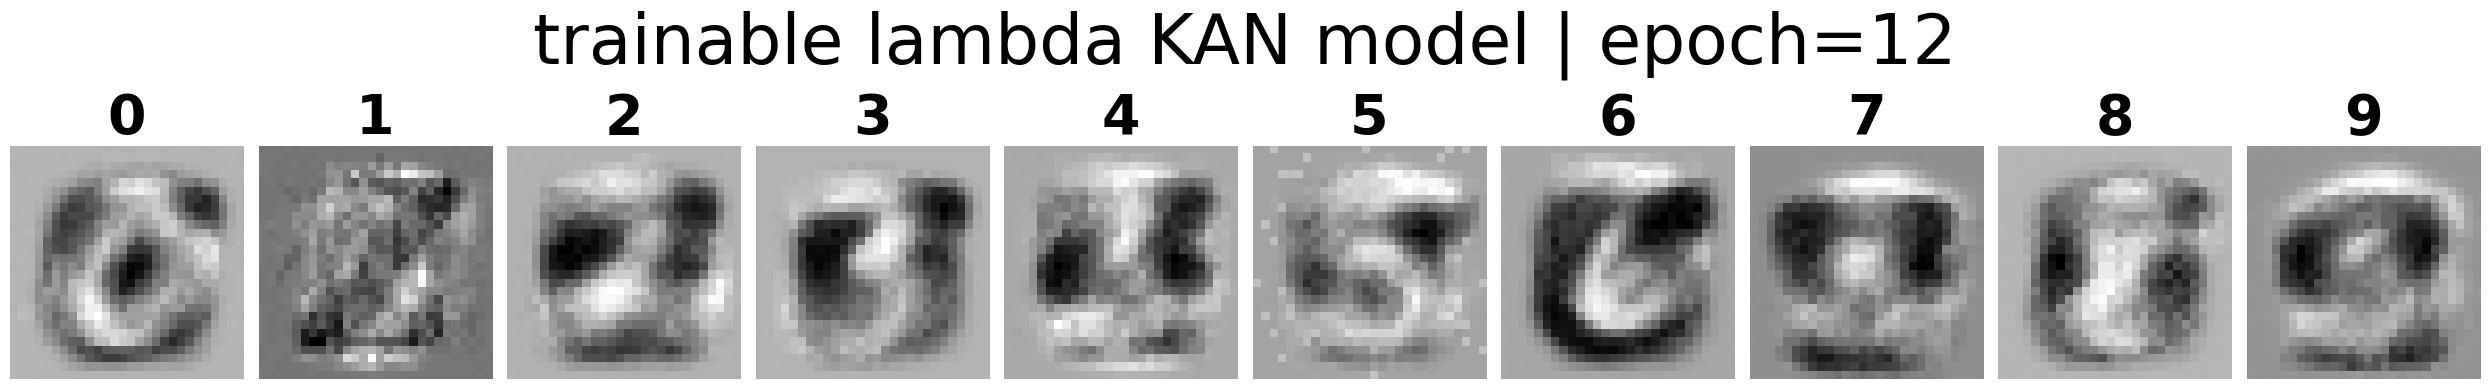

Epoch 12: 100%|██████████| 196/196 [00:26<00:00,  7.54it/s, v_num=0, loss=0.149] Shape with bias: (784, 10)


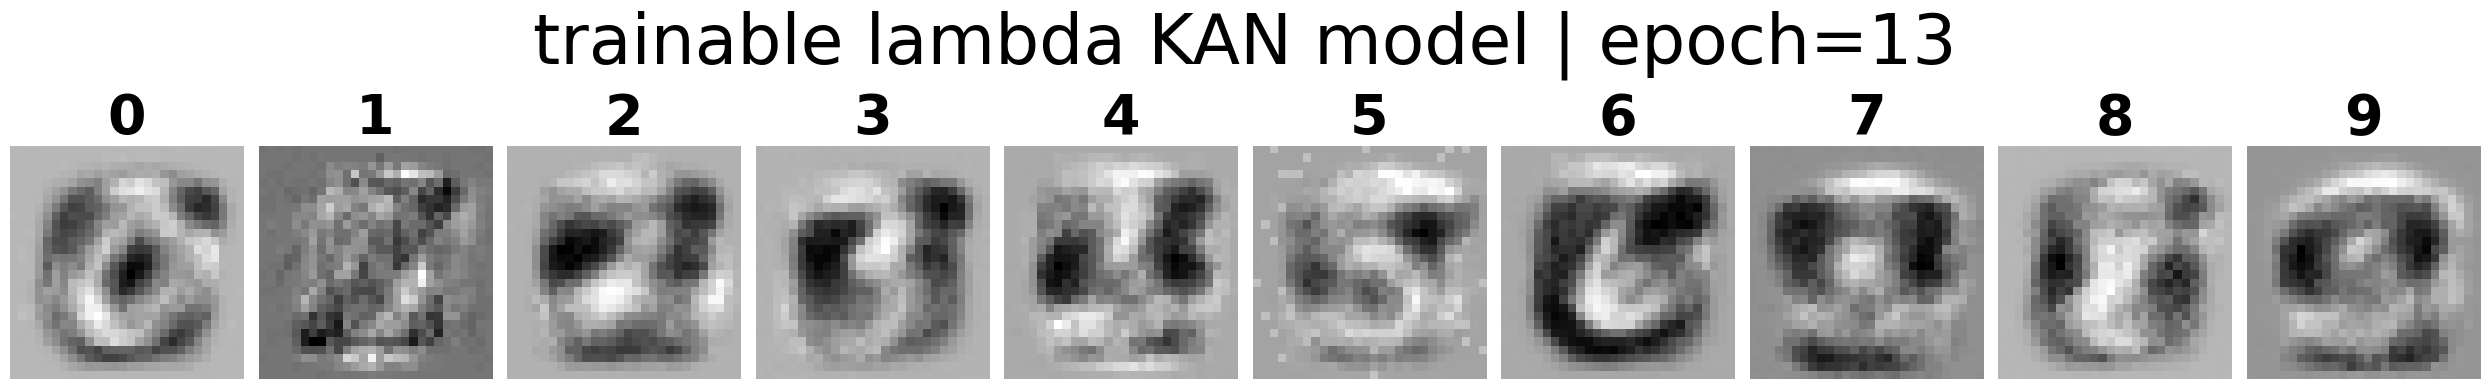

Epoch 13: 100%|██████████| 196/196 [00:26<00:00,  7.53it/s, v_num=0, loss=0.111] Shape with bias: (784, 10)


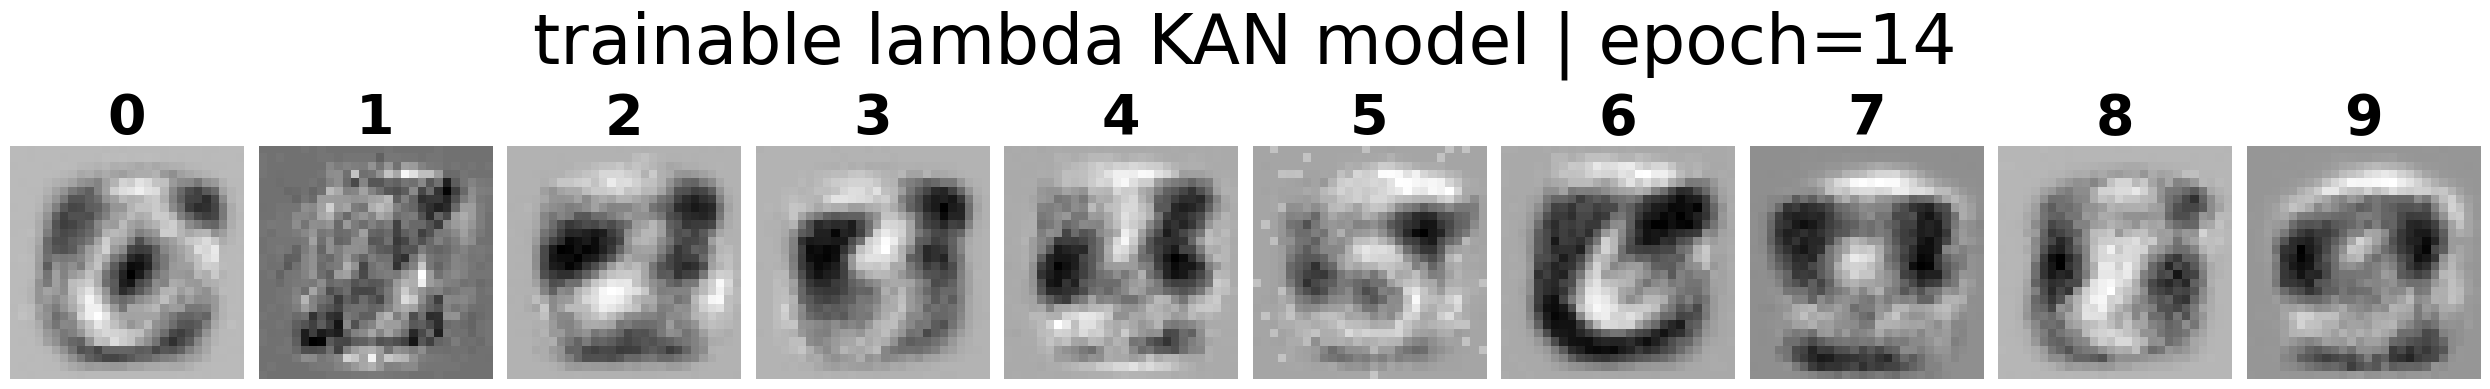

Epoch 14: 100%|██████████| 196/196 [00:26<00:00,  7.52it/s, v_num=0, loss=0.171] Shape with bias: (784, 10)


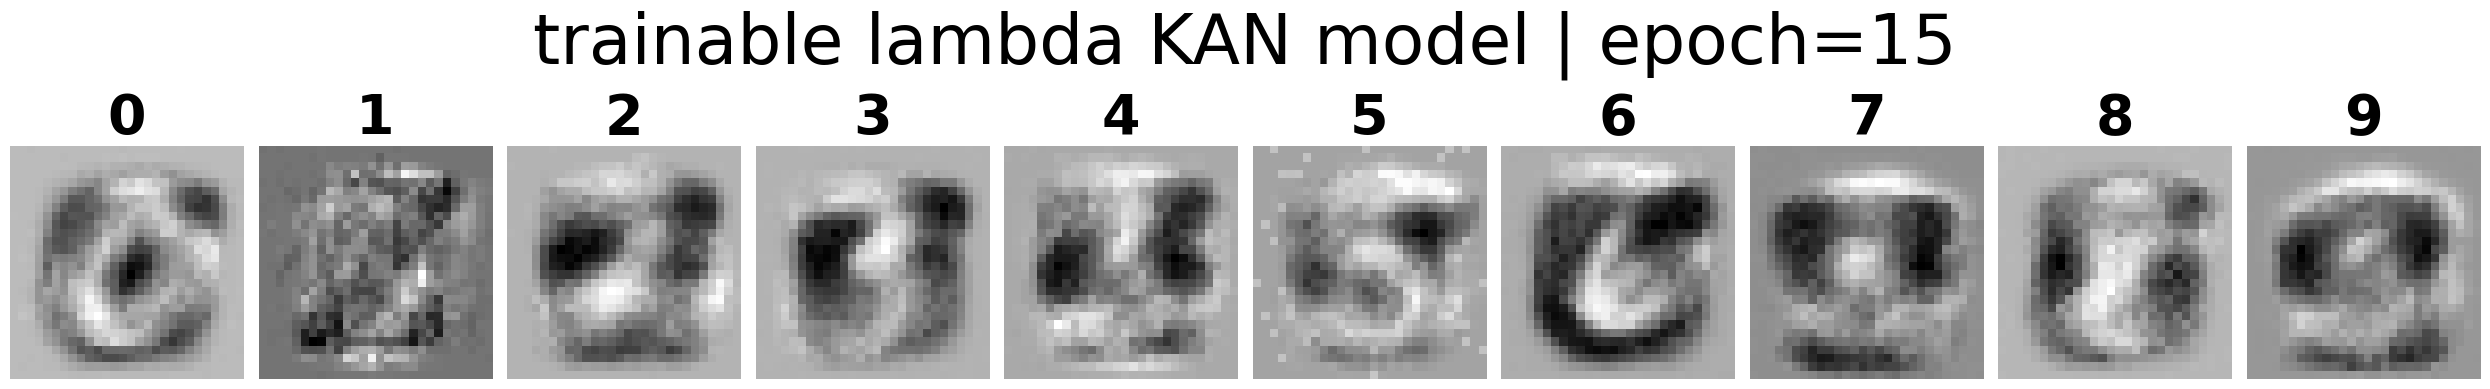

Epoch 15: 100%|██████████| 196/196 [00:26<00:00,  7.51it/s, v_num=0, loss=0.0931]Shape with bias: (784, 10)


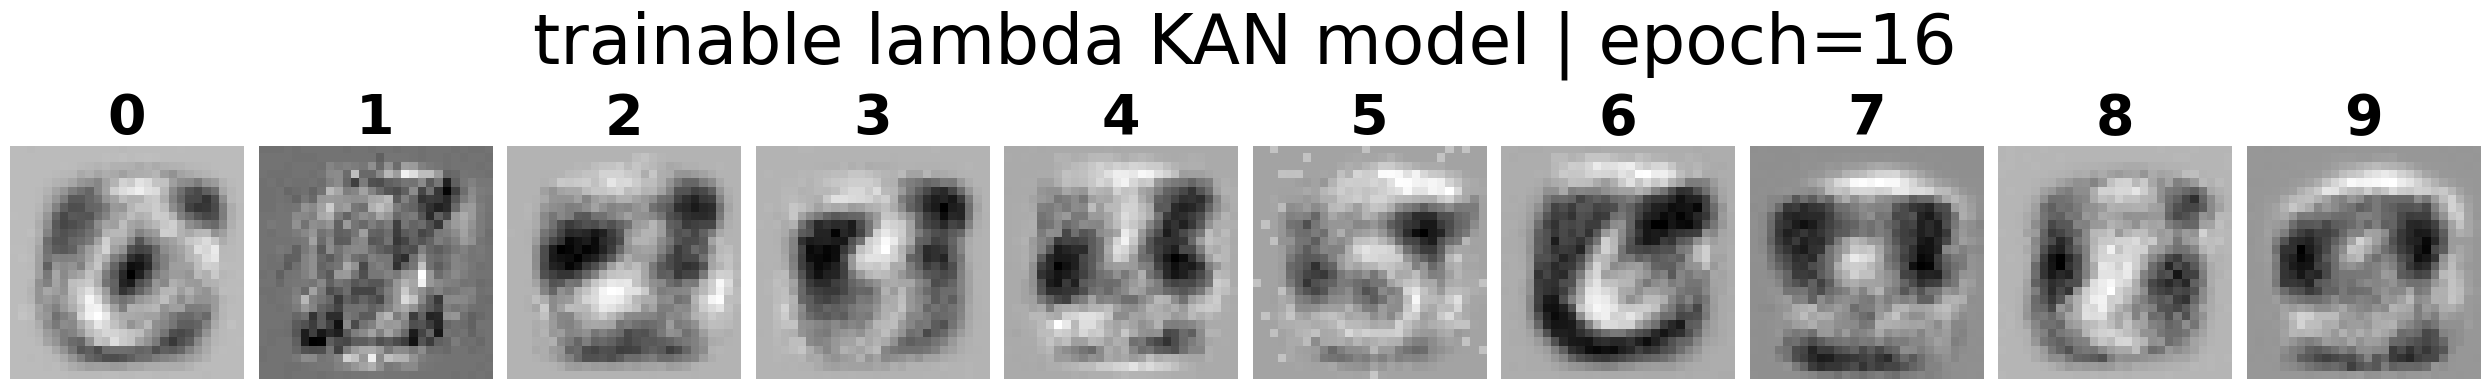

Epoch 16: 100%|██████████| 196/196 [00:26<00:00,  7.50it/s, v_num=0, loss=0.102] Shape with bias: (784, 10)


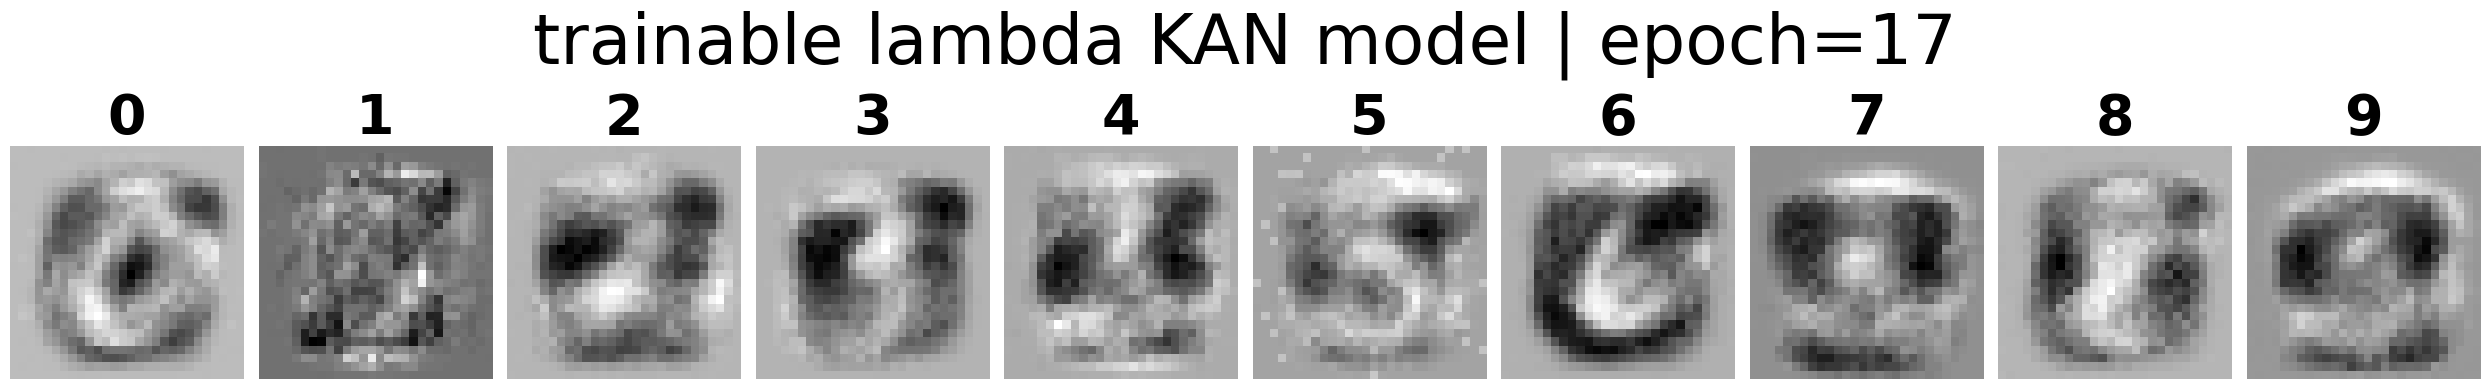

Epoch 17: 100%|██████████| 196/196 [00:26<00:00,  7.51it/s, v_num=0, loss=0.094] Shape with bias: (784, 10)


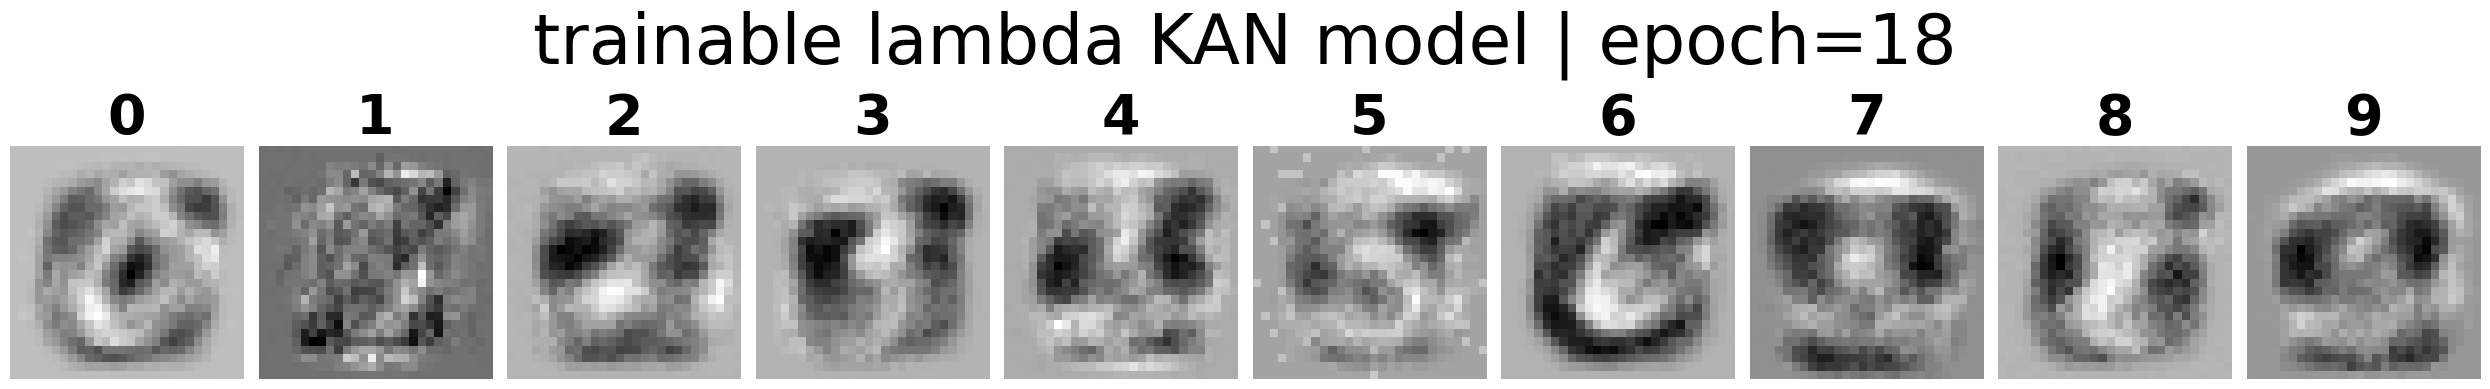

Epoch 18: 100%|██████████| 196/196 [00:26<00:00,  7.51it/s, v_num=0, loss=0.0501]Shape with bias: (784, 10)


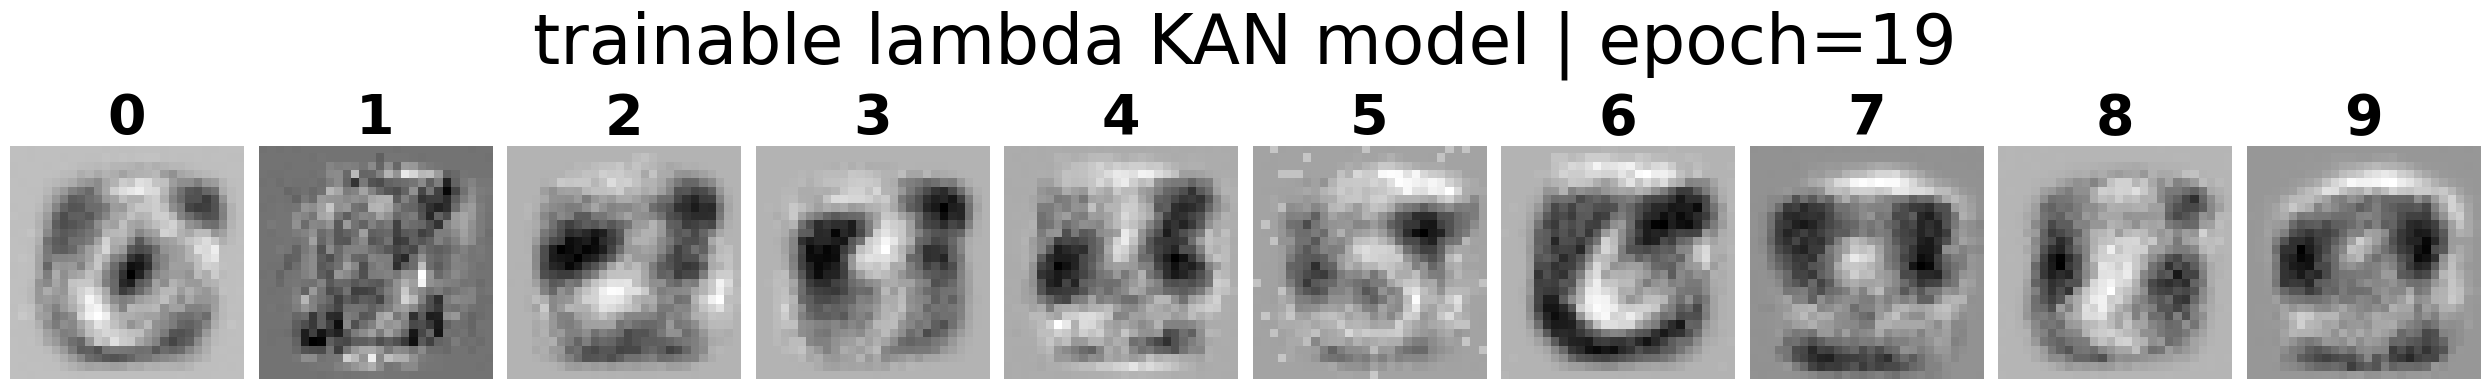

Epoch 19: 100%|██████████| 196/196 [00:26<00:00,  7.51it/s, v_num=0, loss=0.0588]Shape with bias: (784, 10)


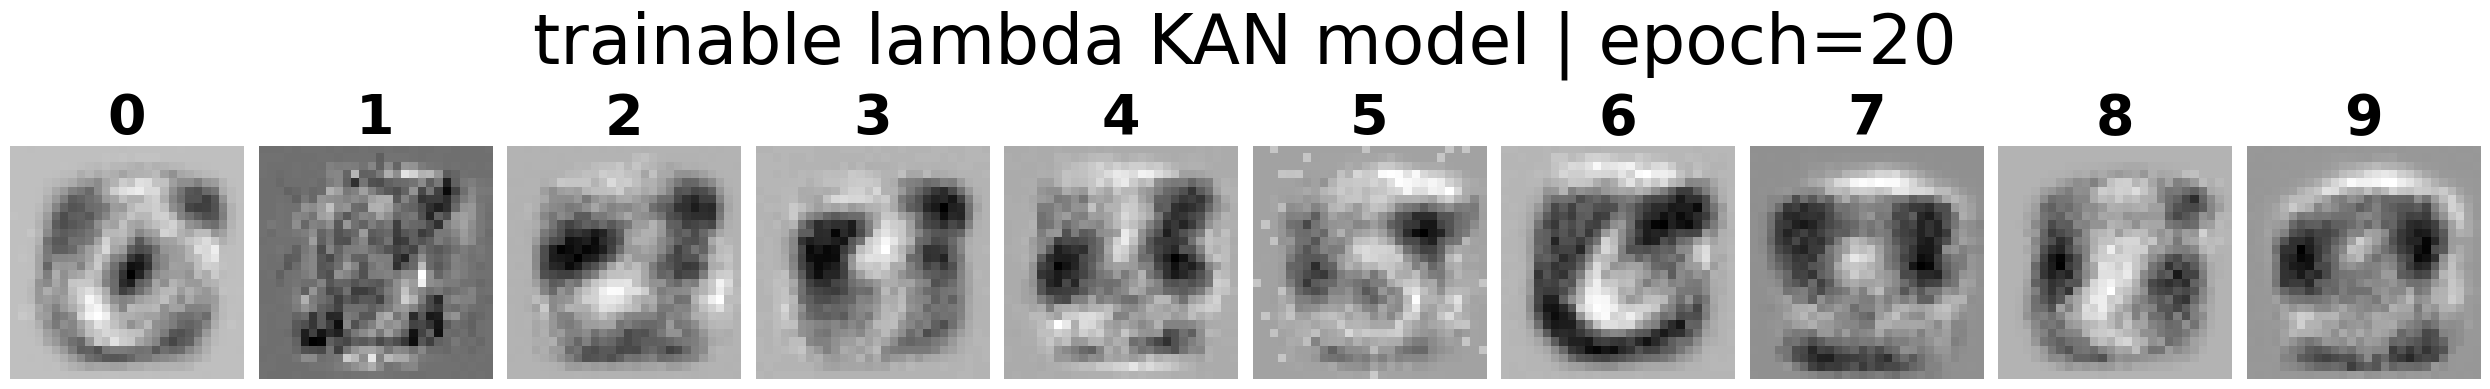

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 196/196 [00:26<00:00,  7.29it/s, v_num=0, loss=0.0588]


In [4]:
class LModel_save_pic(LModel):
    def on_train_epoch_end(self):
        self.log_dict(self.train_metrics.compute())
        self.train_metrics.reset()
        
        val_metrics = self.val_metrics.compute()
        self.log_dict(val_metrics)
        self.val_metrics.reset()
        
        directory = self.logger.log_dir + '\\sens_pic'
        if not os.path.exists(directory):
            os.makedirs(directory)
        show_sensitivity(W = self.model.get_W(),
                         title = f'trainable lambda KAN model | epoch={self.current_epoch+1}',
                         save_pic=True, 
                         file_path=directory + f'\\{self.current_epoch}.png')

checkpoint_callback = ModelCheckpoint(
    # dirpath='best_ckp/'
    save_last=True,
    every_n_epochs=1,
    save_top_k=1,
    save_weights_only=True,
    monitor="MulticlassAccuracy/val",
    filename="model",
    mode="max",
)

L.seed_everything(1755)

model = Mnist_tlmdSplineKAN() #Mnist_lmdSplineKAN() #MnistPrllSplineKAN() #MnistSplineKAN() #MnistSplineKAN() #MnistKAN() #MnistMLP() #MnistCNN() #MnistLR()
pl_model = LModel_save_pic(model)
trainer = L.Trainer(
    max_epochs=20,
    callbacks=[checkpoint_callback],
    num_sanity_val_steps=0,
    log_every_n_steps=10,
    logger=L.pytorch.loggers.TensorBoardLogger(save_dir=f"./logs/{type(model).__name__}/"),
)

trainer.fit(
    model=pl_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

In [5]:
# Load the best checkpoint automatically (lightning tracks this for you)
trainer.test(
    model=pl_model, dataloaders=test_loader, verbose=True, ckpt_path="best"
)

Restoring states from the checkpoint path at ./logs/Mnist_tlmdSplineKAN/lightning_logs\version_0\checkpoints\model.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at ./logs/Mnist_tlmdSplineKAN/lightning_logs\version_0\checkpoints\model.ckpt


Testing DataLoader 0: 100%|██████████| 40/40 [00:03<00:00, 12.93it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    MulticlassAccuracy     │    0.9591081142425537     │
└───────────────────────────┴───────────────────────────┘

[{'MulticlassAccuracy': 0.9591081142425537}]

In [ ]:
# Параметры
model = Mnist_tlmdSplineKAN()
l_seeds = [13, 14, 15, 16, 17]

# Запуск экспериментов
results_df = run_experiments_with_seeds(
    model=model,
    l_seeds=l_seeds,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    max_epochs=20,
    output_csv="stats_results/Mnist_lmdSplineKAN.csv"
)

# Просмотр результатов
print("\nТаблица результатов:")
print(results_df)

### Plot training curve, if needed

In [8]:
log_dir_LR = 'logs\\MnistLR\\lightning_logs\\version_0'
log_dir_MLP = 'logs\\MnistMLP\\lightning_logs\\version_0'
log_dir_lmdSplineKAN = 'logs\\Mnist_lmdSplineKAN\\lightning_logs\\version_0'
log_dir_tlmdSplineKAN = 'logs\\Mnist_tlmdSplineKAN\\lightning_logs\\version_0'

l_dirs = [log_dir_LR, log_dir_MLP, log_dir_lmdSplineKAN, log_dir_tlmdSplineKAN]
l_names = ['Linear Regression', 'MLP', 'lambda KAN', 'trainable lambda KAN']

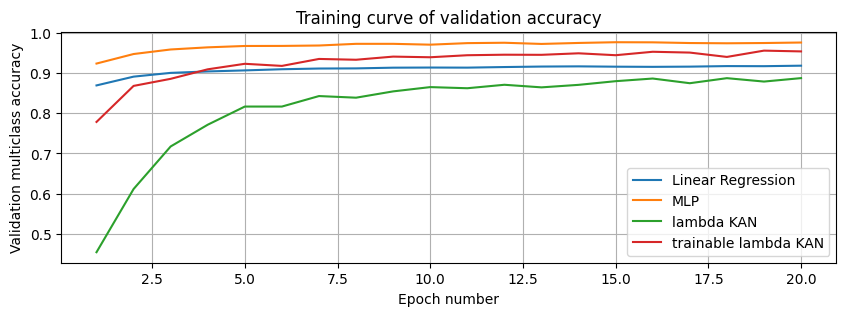

In [9]:
plt.figure(figsize=(10, 3))

for name, log_dir in zip(l_names, l_dirs):
    reader = SummaryReader(log_dir)
    df = reader.scalars

    def drop_nan(df, tag):
        return df[~df[tag].isna()].loc[:, tag]

    acc = drop_nan(df, "MulticlassAccuracy/val").values
    plt.plot(list(range(1, len(acc)+1)), acc, label=name)


plt.xlabel('Epoch number')
plt.ylabel('Validation multiclass accuracy')
plt.title("Training curve of validation accuracy")
plt.grid()
plt.legend(loc="lower right")
plt.show()